# Supporting Information Notebook: PBMC analysis of concept activations and mechanistic alignment

This notebook reproduces the PBMC analysis used in **Results 3.2–3.3** and supports the summary outputs used in the final figure-production workflow.

**Purpose**
- load the upstream PBMC artifacts and aligned regulon prior,
- train and evaluate MM-KPNN on the PBMC stimulation task,
- compute concept activation, selectivity, gradient-based support, mechanistic summary, and stability outputs,
- export standardized tables for downstream figure generation and cross-dataset comparison.

**Primary manuscript links**
- Results 3.2–3.3
- Methods 5.2–5.8

## 1. Reproducibility setup

Initialize paths, seeds, runtime checks, and export locations for the PBMC analysis.

In [1]:
# === 02_train_and_interpret.ipynb : Cell 1 ===
# Reproducibility + project paths + state integrity header
# Run this cell first, and rerun it after any kernel restart.

from __future__ import annotations

import os
import sys
import json
import random
import hashlib
import platform
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd

# Optional torch import guard
try:
    import torch
    TORCH_AVAILABLE = True
except Exception:
    torch = None
    TORCH_AVAILABLE = False

# -----------------------------
# Project identity
# -----------------------------
PROJECT_NAME = "MM-KPNN"
NOTEBOOK_NAME = "02_train_and_interpret"
RUN_LABEL = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")

# -----------------------------
# Dedicated project root
# -----------------------------
PROJECT_ROOT = Path.home() / "Desktop" / "MM-KPNN"

DIRS = {
    "project_root": PROJECT_ROOT,
    "notebooks": PROJECT_ROOT / "notebooks",
    "data": PROJECT_ROOT / "data",
    "artifacts": PROJECT_ROOT / "artifacts",
    "cache": PROJECT_ROOT / "cache",
    "exports": PROJECT_ROOT / "exports",
    "logs": PROJECT_ROOT / "logs",
}

for path in DIRS.values():
    path.mkdir(parents=True, exist_ok=True)

NOTEBOOKS_DIR = DIRS["notebooks"]
DATA_DIR = DIRS["data"]
ARTIFACTS_DIR = DIRS["artifacts"]
CACHE_DIR = DIRS["cache"]
EXPORT_DIR = DIRS["exports"]
LOG_DIR = DIRS["logs"]

# -----------------------------
# Determinism
# -----------------------------
SEED = 19
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

if TORCH_AVAILABLE:
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    try:
        torch.use_deterministic_algorithms(True)
    except Exception:
        pass
    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

# -----------------------------
# Lightweight state registry
# -----------------------------
STATE = {
    "project_name": PROJECT_NAME,
    "notebook_name": NOTEBOOK_NAME,
    "run_label": RUN_LABEL,
    "seed": SEED,
    "started_utc": datetime.now(timezone.utc).isoformat(),
    "paths": {k: str(v.resolve()) for k, v in DIRS.items()},
    "env": {
        "python": sys.version.split()[0],
        "platform": platform.platform(),
        "executable": sys.executable,
        "torch_available": TORCH_AVAILABLE,
        "torch_version": getattr(torch, "__version__", None) if TORCH_AVAILABLE else None,
        "cuda_available": bool(torch.cuda.is_available()) if TORCH_AVAILABLE else False,
        "cuda_device_count": int(torch.cuda.device_count()) if TORCH_AVAILABLE else 0,
    },
    "inputs": {},
    "model": {},
    "training": {},
    "interpretability": {},
    "checks": {},
}

def _sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    h = hashlib.sha256()
    with open(path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()

def nested_register(section: str, key: str, value, overwrite: bool = True) -> None:
    if section not in STATE:
        STATE[section] = {}
    if (key in STATE[section]) and (not overwrite):
        raise KeyError(f"STATE['{section}']['{key}'] already exists and overwrite=False")
    STATE[section][key] = value

def require(condition: bool, message: str) -> None:
    if not condition:
        raise RuntimeError(message)

def save_state(path: Path | None = None) -> Path:
    if path is None:
        path = LOG_DIR / f"{NOTEBOOK_NAME}_{RUN_LABEL}_state.json"
    with open(path, "w", encoding="utf-8") as f:
        json.dump(STATE, f, indent=2, sort_keys=True)
    return path

# -----------------------------
# Notebook 2 invariants
# -----------------------------
INVARIANTS = {
    "artifacts_loaded": False,
    "gene_universe_verified": False,
    "concept_mask_loaded": False,
    "train_split_defined": False,
    "model_instantiated": False,
    "training_completed": False,
    "bottleneck_extracted": False,
    "attribution_completed": False,
}
nested_register("checks", "invariants", INVARIANTS.copy(), overwrite=True)

# -----------------------------
# Expected upstream artifacts
# -----------------------------
EXPECTED_ARTIFACTS = {
    "gene_universe": ARTIFACTS_DIR / "gene_universe.tsv",
    "gene_identifier_audit": ARTIFACTS_DIR / "gene_identifier_audit.tsv",
    "pruned_regulons": ARTIFACTS_DIR / "tf_regulons_pruned.tsv",
}

nested_register(
    "inputs",
    "expected_artifacts",
    {k: str(v.resolve()) for k, v in EXPECTED_ARTIFACTS.items()},
    overwrite=True
)

print(f"{PROJECT_NAME} | {NOTEBOOK_NAME}")
print(f"run_label      : {RUN_LABEL}")
print(f"project_root   : {PROJECT_ROOT.resolve()}")
print(f"python         : {STATE['env']['python']}")
print(f"torch_available: {STATE['env']['torch_available']}")
if TORCH_AVAILABLE:
    print(f"torch_version  : {STATE['env']['torch_version']}")
    print(f"cuda_available : {STATE['env']['cuda_available']}")
    print(f"cuda_devices   : {STATE['env']['cuda_device_count']}")

print("\nExpected upstream artifacts")
for name, path in EXPECTED_ARTIFACTS.items():
    print(f"{name:>20}: {path.resolve()}")

state_path = save_state()
print(f"\nstate_log      : {state_path.resolve()}")

MM-KPNN | 02_train_and_interpret
run_label      : 20260328T164737Z
project_root   : /Users/sally/Desktop/MM-KPNN
python         : 3.10.13
torch_available: True
torch_version  : 1.12.1
cuda_available : False
cuda_devices   : 0

Expected upstream artifacts
       gene_universe: /Users/sally/Desktop/MM-KPNN/artifacts/gene_universe.tsv
gene_identifier_audit: /Users/sally/Desktop/MM-KPNN/artifacts/gene_identifier_audit.tsv
     pruned_regulons: /Users/sally/Desktop/MM-KPNN/artifacts/tf_regulons_pruned.tsv

state_log      : /Users/sally/Desktop/MM-KPNN/logs/02_train_and_interpret_20260328T164737Z_state.json


### Load upstream artifacts

Load the PBMC dataset, frozen gene universe, and regulon library generated in the upstream preprocessing notebook.

In [2]:
# === 02_train_and_interpret.ipynb : Cell 2 ===
# Verify and load upstream artifacts from Notebook 1 -GSE178429

import pandas as pd

artifact_paths = EXPECTED_ARTIFACTS.copy()

print("Checking upstream artifacts\n")
for key, path in artifact_paths.items():
    print(f"{key:>20}: {'FOUND' if path.exists() else 'MISSING'} | {path}")

require(all(path.exists() for path in artifact_paths.values()),
        "One or more required Notebook 1 artifacts are missing.")

gene_universe = pd.read_csv(artifact_paths["gene_universe"], sep="\t")
gene_audit = pd.read_csv(artifact_paths["gene_identifier_audit"], sep="\t")
pruned_regulons = pd.read_csv(artifact_paths["pruned_regulons"], sep="\t")

print("\nLoaded artifacts")
print(f"gene_universe shape : {gene_universe.shape}")
print(f"gene_audit shape    : {gene_audit.shape}")
print(f"pruned_regulons     : {pruned_regulons.shape}")

require("gene_symbol" in gene_universe.columns, "gene_universe.tsv must contain 'gene_symbol'")
require("gene_symbol" in gene_audit.columns, "gene_identifier_audit.tsv must contain 'gene_symbol'")
require({"tf", "target"}.issubset(pruned_regulons.columns),
        "tf_regulons_pruned.tsv must contain 'tf' and 'target'")

artifact_hashes = {
    key: _sha256_file(path)
    for key, path in artifact_paths.items()
}

nested_register("inputs", "artifact_hashes", artifact_hashes, overwrite=True)
nested_register("inputs", "artifact_shapes", {
    "gene_universe": list(gene_universe.shape),
    "gene_identifier_audit": list(gene_audit.shape),
    "pruned_regulons": list(pruned_regulons.shape),
}, overwrite=True)

nested_register("checks", "invariants", {
    **STATE["checks"]["invariants"],
    "artifacts_loaded": True
}, overwrite=True)

print("\nArtifact hashes")
for key, h in artifact_hashes.items():
    print(f"{key:>20}: {h[:16]}...")

state_path = save_state()
print(f"\nupdated_state_log: {state_path.resolve()}")

Checking upstream artifacts

       gene_universe: FOUND | /Users/sally/Desktop/MM-KPNN/artifacts/gene_universe.tsv
gene_identifier_audit: FOUND | /Users/sally/Desktop/MM-KPNN/artifacts/gene_identifier_audit.tsv
     pruned_regulons: FOUND | /Users/sally/Desktop/MM-KPNN/artifacts/tf_regulons_pruned.tsv

Loaded artifacts
gene_universe shape : (19222, 2)
gene_audit shape    : (19222, 7)
pruned_regulons     : (78423, 4)

Artifact hashes
       gene_universe: ba8cbef850cc59ea...
gene_identifier_audit: 974f6d2ade210cfc...
     pruned_regulons: d6a1dbaa89de545d...

updated_state_log: /Users/sally/Desktop/MM-KPNN/logs/02_train_and_interpret_20260328T164737Z_state.json


## 2. Data reconstruction and model inputs

### Reconstruct the PBMC benchmark dataset

Rebuild the analysis-ready AnnData object and verify alignment with the frozen gene universe.

In [3]:
# === 02_train_and_interpret.ipynb : Cell 3 ===
# Rebuild the benchmark AnnData subset and verify gene-universe identity

import gzip
import pandas as pd
import anndata as ad
from scipy import io
from scipy import sparse

# Reuse the GEO processed triplet
GSE178429_DIR = DATA_DIR / "GSE178429"
cellmeta_path = GSE178429_DIR / "GSE178429_PBMCs_stim_scRNAseq_cellMeta.txt.gz"
counts_path = GSE178429_DIR / "GSE178429_PBMCs_stim_scRNAseq_counts.txt.gz"
genes_path = GSE178429_DIR / "GSE178429_PBMCs_stim_scRNAseq_geneNames.txt.gz"

require(cellmeta_path.exists(), f"Missing file: {cellmeta_path}")
require(counts_path.exists(), f"Missing file: {counts_path}")
require(genes_path.exists(), f"Missing file: {genes_path}")

print("Loading GSE178429 files...")
cell_meta = pd.read_csv(cellmeta_path, sep="\t", compression="gzip")
gene_names = pd.read_csv(genes_path, sep="\t", header=None, compression="gzip")

with gzip.open(counts_path, "rt") as fh:
    X = io.mmread(fh)

if not sparse.issparse(X):
    X = sparse.csr_matrix(X)
else:
    X = X.tocsr()

# Resolve orientation
n_meta_cells = cell_meta.shape[0]
n_genes_list = gene_names.shape[0]

if X.shape == (n_meta_cells, n_genes_list):
    pass
elif X.shape == (n_genes_list, n_meta_cells):
    X = X.T.tocsr()
else:
    raise RuntimeError(
        f"Counts matrix shape mismatch: matrix={X.shape}, "
        f"metadata cells={n_meta_cells}, genes={n_genes_list}"
    )

# Build AnnData
if gene_names.shape[1] == 1:
    var = pd.DataFrame(index=gene_names.iloc[:, 0].astype(str).values)
    var.index.name = "gene_symbol"
else:
    var = gene_names.copy()
    var.columns = [f"gene_col_{i}" for i in range(var.shape[1])]
    var.index = var.iloc[:, 0].astype(str).values
    var.index.name = "gene_symbol"

obs = cell_meta.copy()
obs.index = obs.index.astype(str)

adata = ad.AnnData(X=X, obs=obs, var=var)
adata.var_names_make_unique()

# Recreate parsed fields from Notebook 1
adata.obs["condition_str"] = adata.obs["Condition"].astype(str)
adata.obs["stim_type"] = adata.obs["StimType"].astype(str)
adata.obs["donor"] = adata.obs["Donor"].astype(str)
adata.obs["has_golgiplug"] = adata.obs["condition_str"].str.contains("GolgiPlug", case=False, regex=False)

def parse_timepoint(cond: str) -> str:
    if "_1h" in cond:
        return "1h"
    if "_6h" in cond:
        return "6h"
    return "unknown"

adata.obs["timepoint"] = adata.obs["condition_str"].map(parse_timepoint)

primary_mask = (~adata.obs["has_golgiplug"]) & (adata.obs["timepoint"].isin(["1h", "6h"]))
adata_primary = adata[primary_mask].copy()

print("\nRebuilt primary benchmark subset")
print(adata_primary)

# Verify gene-universe identity
frozen_genes = pd.Index(gene_universe["gene_symbol"].astype(str))
adata_genes = pd.Index(adata_primary.var_names.astype(str))

print("\nGene-universe check")
print(f"Frozen genes     : {len(frozen_genes)}")
print(f"adata_primary    : {len(adata_genes)}")

require(len(frozen_genes) == len(adata_genes),
        "Gene universe length mismatch between Notebook 1 artifact and rebuilt adata.")
require(frozen_genes.equals(adata_genes),
        "Gene order mismatch between Notebook 1 frozen gene universe and rebuilt adata.")

nested_register("inputs", "adata_primary_shape", {
    "n_cells": int(adata_primary.n_obs),
    "n_genes": int(adata_primary.n_vars),
}, overwrite=True)

nested_register("checks", "invariants", {
    **STATE["checks"]["invariants"],
    "gene_universe_verified": True
}, overwrite=True)

print("\nGene-universe identity verified ✅")

state_path = save_state()
print(f"\nupdated_state_log: {state_path.resolve()}")

Loading GSE178429 files...

Rebuilt primary benchmark subset
AnnData object with n_obs × n_vars = 19268 × 19222
    obs: 'cellBarcode', 'nCount_RNA', 'nFeature_RNA', 'Condition', 'StimType', 'Donor', 'condition_str', 'stim_type', 'donor', 'has_golgiplug', 'timepoint'

Gene-universe check
Frozen genes     : 19222
adata_primary    : 19222

Gene-universe identity verified ✅

updated_state_log: /Users/sally/Desktop/MM-KPNN/logs/02_train_and_interpret_20260328T164737Z_state.json


/var/folders/r2/x9gghyl142nb0hbyp7f4mhzh0000gn/T/ipykernel_54744/443960712.py:59: FutureWarning: X.dtype being converted to np.float32 from int64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  adata = ad.AnnData(X=X, obs=obs, var=var)


## 3. Model construction

### Build the gene-by-concept mask

Construct the fixed gene-by-concept mask used to define the MM-KPNN bottleneck.

In [4]:
# === 02_train_and_interpret.ipynb : Cell 4 ===
# Build the gene × concept mask from pruned TF regulons

import numpy as np
import pandas as pd

frozen_genes = pd.Index(gene_universe["gene_symbol"].astype(str))
concept_names = pd.Index(sorted(pruned_regulons["tf"].astype(str).unique()))

gene_to_idx = {g: i for i, g in enumerate(frozen_genes)}
concept_to_idx = {c: j for j, c in enumerate(concept_names)}

n_genes = len(frozen_genes)
n_concepts = len(concept_names)

mask = np.zeros((n_genes, n_concepts), dtype=np.float32)

mapped_edges = 0
skipped_edges = 0

for row in pruned_regulons.itertuples(index=False):
    tf = str(row.tf)
    target = str(row.target)

    if (target in gene_to_idx) and (tf in concept_to_idx):
        i = gene_to_idx[target]
        j = concept_to_idx[tf]
        mask[i, j] = 1.0
        mapped_edges += 1
    else:
        skipped_edges += 1

mask_df = pd.DataFrame(mask, index=frozen_genes, columns=concept_names)

print("Gene × concept mask")
print(f"mask shape        : {mask_df.shape}")
print(f"mapped edges      : {mapped_edges:,}")
print(f"skipped edges     : {skipped_edges:,}")
print(f"mask density      : {mask.sum() / mask.size:.6f}")

# Concept and gene coverage diagnostics
concept_sizes = mask_df.sum(axis=0).sort_values(ascending=False)
gene_concept_degree = mask_df.sum(axis=1).sort_values(ascending=False)

print("\nConcept size summary")
display(concept_sizes.describe())

print("\nGene degree summary")
display(gene_concept_degree.describe())

print("\nLargest concepts")
display(concept_sizes.head(15))

print("\nGenes with highest concept degree")
display(gene_concept_degree.head(15))

# Save mask artifacts
mask_path = ARTIFACTS_DIR / "gene_concept_mask.tsv"
concept_sizes_path = ARTIFACTS_DIR / "concept_sizes.tsv"
gene_degree_path = ARTIFACTS_DIR / "gene_concept_degree.tsv"

mask_df.to_csv(mask_path, sep="\t")
concept_sizes.rename("concept_size").to_csv(concept_sizes_path, sep="\t")
gene_concept_degree.rename("gene_concept_degree").to_csv(gene_degree_path, sep="\t")

nested_register("model", "mask_shape", {
    "n_genes": int(mask_df.shape[0]),
    "n_concepts": int(mask_df.shape[1]),
}, overwrite=True)

nested_register("model", "mask_stats", {
    "mapped_edges": int(mapped_edges),
    "skipped_edges": int(skipped_edges),
    "density": float(mask.sum() / mask.size),
    "genes_with_any_concept": int((gene_concept_degree > 0).sum()),
    "genes_without_concept": int((gene_concept_degree == 0).sum()),
    "concepts_with_any_gene": int((concept_sizes > 0).sum()),
}, overwrite=True)

nested_register("model", "mask_artifacts", {
    "mask_path": str(mask_path.resolve()),
    "concept_sizes_path": str(concept_sizes_path.resolve()),
    "gene_degree_path": str(gene_degree_path.resolve()),
}, overwrite=True)

nested_register("checks", "invariants", {
    **STATE["checks"]["invariants"],
    "concept_mask_loaded": True
}, overwrite=True)

print(f"\nSaved mask: {mask_path.resolve()}")
print(f"Saved concept sizes: {concept_sizes_path.resolve()}")
print(f"Saved gene degrees: {gene_degree_path.resolve()}")

state_path = save_state()
print(f"\nupdated_state_log: {state_path.resolve()}")

Gene × concept mask
mask shape        : (19222, 315)
mapped edges      : 78,423
skipped edges     : 0
mask density      : 0.012952

Concept size summary


count    315.000000
mean     248.961899
std      179.943954
min       10.000000
25%       35.000000
50%      300.000000
75%      423.000000
max      499.000000
dtype: float64


Gene degree summary


count    19222.000000
mean         4.079856
std         10.004474
min          0.000000
25%          0.000000
50%          1.000000
75%          3.000000
max        191.000000
dtype: float64


Largest concepts


ZNF143    499.0
PPARG     495.0
SETDB1    494.0
ETV4      494.0
CREM      491.0
TP63      490.0
TCF3      487.0
ARNT      486.0
SMAD3     485.0
ATF2      482.0
SMAD1     478.0
CEBPD     477.0
HBP1      477.0
RUNX3     472.0
PGR       472.0
dtype: float32


Genes with highest concept degree


gene_symbol
PRPF31      191.0
RUNX1       144.0
GSE1        141.0
FOXP1       127.0
BHLHE40     126.0
RERE        125.0
ARHGAP26    116.0
FNDC3B      110.0
CTC1        109.0
ZMYND8      106.0
MSI2        104.0
ZMIZ1       104.0
PRKCH       103.0
SMAD3       102.0
MACF1       101.0
dtype: float32


Saved mask: /Users/sally/Desktop/MM-KPNN/artifacts/gene_concept_mask.tsv
Saved concept sizes: /Users/sally/Desktop/MM-KPNN/artifacts/concept_sizes.tsv
Saved gene degrees: /Users/sally/Desktop/MM-KPNN/artifacts/gene_concept_degree.tsv

updated_state_log: /Users/sally/Desktop/MM-KPNN/logs/02_train_and_interpret_20260328T164737Z_state.json


### Define labels and train/validation/test splits

Specify the PBMC stimulation target and create reproducible data splits.

In [5]:
# === 02_train_and_interpret.ipynb : Cell 5 ===
# Define primary prediction target and reproducible train/validation/test splits


from sklearn.model_selection import train_test_split

# -------------------------------------------------
# Primary benchmark task
# -------------------------------------------------
TARGET_COLUMN = "stim_type"

require(TARGET_COLUMN in adata_primary.obs.columns,
        f"Missing target column: {TARGET_COLUMN}")

# Write target label directly into adata_primary.obs
adata_primary.obs["target_label"] = adata_primary.obs[TARGET_COLUMN].astype(str)

print("Primary target definition")
print(f"target column : {TARGET_COLUMN}")
print("\nTarget counts")
print(adata_primary.obs["target_label"].value_counts())

# -------------------------------------------------
# Reproducible cell-level split
# -------------------------------------------------
all_idx = np.arange(adata_primary.n_obs)

train_idx, temp_idx = train_test_split(
    all_idx,
    test_size=0.30,
    random_state=SEED,
    stratify=adata_primary.obs["target_label"]
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    random_state=SEED,
    stratify=adata_primary.obs.iloc[temp_idx]["target_label"]
)

split = pd.Series(index=adata_primary.obs.index, dtype="object")
split.iloc[train_idx] = "train"
split.iloc[val_idx] = "val"
split.iloc[test_idx] = "test"

adata_primary.obs["split"] = split.astype("category")

print("\nSplit counts")
print(adata_primary.obs["split"].value_counts())

print("\nSplit × target")
display(pd.crosstab(adata_primary.obs["split"], adata_primary.obs["target_label"]))

print("\nSplit × donor")
display(pd.crosstab(adata_primary.obs["split"], adata_primary.obs["donor"]))

print("\nSplit × timepoint")
display(pd.crosstab(adata_primary.obs["split"], adata_primary.obs["timepoint"]))

# -------------------------------------------------
# Save split artifact
# -------------------------------------------------
split_df = adata_primary.obs.loc[:, [
    "cellBarcode", "condition_str", "stim_type", "target_label", "timepoint", "donor", "split"
]].copy()

split_path = ARTIFACTS_DIR / "benchmark_splits.tsv"
split_df.to_csv(split_path, sep="\t", index=True)

# -------------------------------------------------
# Register state
# -------------------------------------------------
nested_register("training", "task_definition", {
    "target_column": TARGET_COLUMN,
    "target_classes": sorted(map(str, adata_primary.obs["target_label"].unique())),
    "n_classes": int(adata_primary.obs["target_label"].nunique()),
    "n_cells": int(adata_primary.n_obs),
}, overwrite=True)

nested_register("training", "split_sizes", {
    "train": int((adata_primary.obs["split"] == "train").sum()),
    "val": int((adata_primary.obs["split"] == "val").sum()),
    "test": int((adata_primary.obs["split"] == "test").sum()),
}, overwrite=True)

nested_register("training", "split_artifact", {
    "path": str(split_path.resolve()),
}, overwrite=True)

nested_register("checks", "invariants", {
    **STATE["checks"]["invariants"],
    "train_split_defined": True
}, overwrite=True)

print(f"\nSaved split artifact: {split_path.resolve()}")

state_path = save_state()
print(f"\nupdated_state_log: {state_path.resolve()}")

Primary target definition
target column : stim_type

Target counts
target_label
Control    5802
PMA        5600
LPS        5408
IFN        2458
Name: count, dtype: int64

Split counts
split
train    13487
test      2891
val       2890
Name: count, dtype: int64

Split × target


target_label,Control,IFN,LPS,PMA
split,,,,
test,871,368,812,840
train,4061,1721,3785,3920
val,870,369,811,840



Split × donor


donor,Donor1,Donor2,Donor3,Donor4
split,,,,
test,665,754,879,593
train,3229,3505,3935,2818
val,682,772,863,573



Split × timepoint


timepoint,1h,6h
split,,
test,1504,1387
train,7048,6439
val,1579,1311



Saved split artifact: /Users/sally/Desktop/MM-KPNN/artifacts/benchmark_splits.tsv

updated_state_log: /Users/sally/Desktop/MM-KPNN/logs/02_train_and_interpret_20260328T164737Z_state.json


### Build model-ready tensors

Convert the aligned expression matrix and labels into tensors for MM-KPNN training.

In [6]:
# === 02_train_and_interpret.ipynb : Cell 6 ===
# Build model-ready tensors for MM-KPNN

from sklearn.preprocessing import LabelEncoder
from scipy import sparse

# -------------------------------------------------
# Expression matrix
# -------------------------------------------------
X = adata_primary.X
if sparse.issparse(X):
    X = X.toarray()

X = np.asarray(X, dtype=np.float32)

# -------------------------------------------------
# Labels
# -------------------------------------------------
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(adata_primary.obs["target_label"].astype(str).values)
class_names = list(label_encoder.classes_)

print("Encoded target classes")
for i, c in enumerate(class_names):
    print(f"{i}: {c}")

# -------------------------------------------------
# Splits
# -------------------------------------------------
train_mask = (adata_primary.obs["split"].astype(str).values == "train")
val_mask = (adata_primary.obs["split"].astype(str).values == "val")
test_mask = (adata_primary.obs["split"].astype(str).values == "test")

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]

print("\nExpression tensor shapes")
print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_val  : {X_val.shape} | y_val  : {y_val.shape}")
print(f"X_test : {X_test.shape} | y_test : {y_test.shape}")

# -------------------------------------------------
# Concept mask tensor
# -------------------------------------------------
mask_tensor = torch.tensor(mask_df.values, dtype=torch.float32) if TORCH_AVAILABLE else None

if TORCH_AVAILABLE:
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

    y_train_tensor = torch.tensor(y_train, dtype=torch.long)
    y_val_tensor = torch.tensor(y_val, dtype=torch.long)
    y_test_tensor = torch.tensor(y_test, dtype=torch.long)

    print("\nTorch tensors created ✅")
    print(f"mask_tensor: {tuple(mask_tensor.shape)}")
else:
    X_train_tensor = X_val_tensor = X_test_tensor = None
    y_train_tensor = y_val_tensor = y_test_tensor = None
    print("\nTorch unavailable; tensors not created.")

# -------------------------------------------------
# Register state
# -------------------------------------------------
nested_register("training", "class_encoding", {
    "class_names": class_names,
    "n_classes": int(len(class_names)),
}, overwrite=True)

nested_register("training", "tensor_shapes", {
    "X_train": list(X_train.shape),
    "X_val": list(X_val.shape),
    "X_test": list(X_test.shape),
    "mask": list(mask_df.shape),
}, overwrite=True)

state_path = save_state()
print(f"\nupdated_state_log: {state_path.resolve()}")

Encoded target classes
0: Control
1: IFN
2: LPS
3: PMA

Expression tensor shapes
X_train: (13487, 19222) | y_train: (13487,)
X_val  : (2890, 19222) | y_val  : (2890,)
X_test : (2891, 19222) | y_test : (2891,)

Torch tensors created ✅
mask_tensor: (19222, 315)

updated_state_log: /Users/sally/Desktop/MM-KPNN/logs/02_train_and_interpret_20260328T164737Z_state.json


### Define the MM-KPNN architecture

Instantiate the masked gene-to-concept-to-output model used throughout the notebook.

In [7]:
# === 02_train_and_interpret.ipynb : Cell 7 ===
# Fixed MM-KPNN architecture: masked gene -> concept -> output

import torch
import torch.nn as nn
import torch.nn.functional as F

require(TORCH_AVAILABLE, "PyTorch is required for model instantiation.")

class MMKPNN(nn.Module):
    def __init__(
        self,
        n_genes: int,
        n_concepts: int,
        n_classes: int,
        concept_mask: torch.Tensor,
        concept_activation: str = "relu",
        output_bias: bool = True,
    ):
        super().__init__()

        require(concept_mask.shape == (n_genes, n_concepts),
                f"concept_mask must have shape {(n_genes, n_concepts)}, got {tuple(concept_mask.shape)}")

        self.n_genes = n_genes
        self.n_concepts = n_concepts
        self.n_classes = n_classes

        # Register immutable architectural prior
        self.register_buffer("concept_mask", concept_mask.clone().detach())

        # Gene -> concept parameters (mask enforced in forward)
        self.gene_to_concept = nn.Parameter(torch.empty(n_genes, n_concepts))
        nn.init.xavier_uniform_(self.gene_to_concept)

        self.concept_bias = nn.Parameter(torch.zeros(n_concepts))

        # Concept -> output classifier
        self.concept_to_output = nn.Linear(n_concepts, n_classes, bias=output_bias)

        if concept_activation == "relu":
            self.concept_activation_fn = F.relu
            self.concept_activation_name = "relu"
        elif concept_activation == "softplus":
            self.concept_activation_fn = F.softplus
            self.concept_activation_name = "softplus"
        else:
            raise ValueError(f"Unsupported concept activation: {concept_activation}")

    def masked_gene_to_concept_weights(self) -> torch.Tensor:
        return self.gene_to_concept * self.concept_mask

    def forward(self, x: torch.Tensor, return_concepts: bool = False):
        # x: [batch, n_genes]
        masked_w = self.masked_gene_to_concept_weights()  # [n_genes, n_concepts]
        concept_pre = x @ masked_w + self.concept_bias    # [batch, n_concepts]
        concept_act = self.concept_activation_fn(concept_pre)
        logits = self.concept_to_output(concept_act)

        if return_concepts:
            return logits, concept_act, concept_pre
        return logits

# Instantiate model
n_genes = mask_tensor.shape[0]
n_concepts = mask_tensor.shape[1]
n_classes = len(class_names)

model = MMKPNN(
    n_genes=n_genes,
    n_concepts=n_concepts,
    n_classes=n_classes,
    concept_mask=mask_tensor,
    concept_activation="relu",
    output_bias=True,
)

print(model)

# Quick structural verification
with torch.no_grad():
    masked_w = model.masked_gene_to_concept_weights()
    active_edges = int((masked_w != 0).sum().item())
    total_edges = int(mask_tensor.sum().item())

print("\nModel structural check")
print(f"n_genes        : {model.n_genes}")
print(f"n_concepts     : {model.n_concepts}")
print(f"n_classes      : {model.n_classes}")
print(f"mask shape     : {tuple(model.concept_mask.shape)}")
print(f"allowed edges  : {total_edges:,}")
print(f"active edges   : {active_edges:,}")

require(active_edges == total_edges,
        "Masked parameter structure does not match concept mask support.")

nested_register("model", "architecture", {
    "n_genes": int(model.n_genes),
    "n_concepts": int(model.n_concepts),
    "n_classes": int(model.n_classes),
    "concept_activation": model.concept_activation_name,
    "allowed_edges": total_edges,
}, overwrite=True)

nested_register("checks", "invariants", {
    **STATE["checks"]["invariants"],
    "model_instantiated": True
}, overwrite=True)

state_path = save_state()
print(f"\nupdated_state_log: {state_path.resolve()}")

MMKPNN(
  (concept_to_output): Linear(in_features=315, out_features=4, bias=True)
)

Model structural check
n_genes        : 19222
n_concepts     : 315
n_classes      : 4
mask shape     : (19222, 315)
allowed edges  : 78,423
active edges   : 78,423

updated_state_log: /Users/sally/Desktop/MM-KPNN/logs/02_train_and_interpret_20260328T164737Z_state.json


## 4. Model training

In [8]:
# === 02_train_and_interpret.ipynb : Cell 8 ===
# Deterministic training loop for MM-KPNN

import copy
import torch
import torch.nn as nn
import torch.optim as optim

require(TORCH_AVAILABLE, "PyTorch is required for training.")

# -------------------------------------------------
# Training configuration
# -------------------------------------------------
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5
N_EPOCHS = 60
PRINT_EVERY = 5

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    preds = torch.argmax(logits, dim=1)
    return float((preds == y_true).float().mean().item())

history = []
best_val_loss = float("inf")
best_state_dict = None
best_epoch = None

for epoch in range(1, N_EPOCHS + 1):
    model.train()

    optimizer.zero_grad()
    train_logits = model(X_train_tensor)
    train_loss = criterion(train_logits, y_train_tensor)
    train_loss.backward()
    optimizer.step()

    train_acc = accuracy_from_logits(train_logits, y_train_tensor)

    model.eval()
    with torch.no_grad():
        val_logits = model(X_val_tensor)
        val_loss = criterion(val_logits, y_val_tensor)
        val_acc = accuracy_from_logits(val_logits, y_val_tensor)

    epoch_record = {
        "epoch": epoch,
        "train_loss": float(train_loss.item()),
        "train_acc": float(train_acc),
        "val_loss": float(val_loss.item()),
        "val_acc": float(val_acc),
    }
    history.append(epoch_record)

    if val_loss.item() < best_val_loss:
        best_val_loss = float(val_loss.item())
        best_state_dict = copy.deepcopy(model.state_dict())
        best_epoch = epoch

    if epoch == 1 or epoch % PRINT_EVERY == 0 or epoch == N_EPOCHS:
        print(
            f"Epoch {epoch:03d} | "
            f"train_loss={train_loss.item():.4f} | train_acc={train_acc:.4f} | "
            f"val_loss={val_loss.item():.4f} | val_acc={val_acc:.4f}"
        )

require(best_state_dict is not None, "Training finished without a valid best model state.")

# Restore best validation model
model.load_state_dict(best_state_dict)

# -------------------------------------------------
# Final evaluation on test set
# -------------------------------------------------
model.eval()
with torch.no_grad():
    test_logits = model(X_test_tensor)
    test_loss = criterion(test_logits, y_test_tensor)
    test_acc = accuracy_from_logits(test_logits, y_test_tensor)

history_df = pd.DataFrame(history)

print("\nBest model summary")
print(f"best_epoch : {best_epoch}")
print(f"best_val_loss : {best_val_loss:.6f}")
print(f"test_loss : {test_loss.item():.6f}")
print(f"test_acc  : {test_acc:.6f}")

print("\nTraining history (last 10 epochs)")
display(history_df.tail(10))

# Save training history
history_path = EXPORT_DIR / "training_history.tsv"
history_df.to_csv(history_path, sep="\t", index=False)

nested_register("training", "config", {
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "n_epochs": N_EPOCHS,
    "loss": "cross_entropy",
    "optimizer": "adam",
}, overwrite=True)

nested_register("training", "best_model", {
    "best_epoch": int(best_epoch),
    "best_val_loss": float(best_val_loss),
    "test_loss": float(test_loss.item()),
    "test_acc": float(test_acc),
    "history_path": str(history_path.resolve()),
}, overwrite=True)

nested_register("checks", "invariants", {
    **STATE["checks"]["invariants"],
    "training_completed": True
}, overwrite=True)

print(f"\nSaved training history: {history_path.resolve()}")

state_path = save_state()
print(f"\nupdated_state_log: {state_path.resolve()}")

Epoch 001 | train_loss=1.3843 | train_acc=0.2944 | val_loss=1.3390 | val_acc=0.4789
Epoch 005 | train_loss=1.2003 | train_acc=0.6486 | val_loss=1.1664 | val_acc=0.6651
Epoch 010 | train_loss=0.9844 | train_acc=0.7397 | val_loss=0.9656 | val_acc=0.7356
Epoch 015 | train_loss=0.8040 | train_acc=0.7925 | val_loss=0.8016 | val_acc=0.7765
Epoch 020 | train_loss=0.6666 | train_acc=0.8299 | val_loss=0.6778 | val_acc=0.8052
Epoch 025 | train_loss=0.5653 | train_acc=0.8476 | val_loss=0.5889 | val_acc=0.8211
Epoch 030 | train_loss=0.4905 | train_acc=0.8612 | val_loss=0.5263 | val_acc=0.8308
Epoch 035 | train_loss=0.4343 | train_acc=0.8689 | val_loss=0.4826 | val_acc=0.8360
Epoch 040 | train_loss=0.3906 | train_acc=0.8754 | val_loss=0.4513 | val_acc=0.8388
Epoch 045 | train_loss=0.3555 | train_acc=0.8838 | val_loss=0.4287 | val_acc=0.8401
Epoch 050 | train_loss=0.3268 | train_acc=0.8905 | val_loss=0.4120 | val_acc=0.8415
Epoch 055 | train_loss=0.3024 | train_acc=0.8988 | val_loss=0.3991 | val_acc

,epoch,train_loss,train_acc,val_loss,val_acc
50,51,0.321601,0.892712,0.409139,0.843599
51,52,0.316574,0.894269,0.406377,0.845329
52,53,0.311699,0.895751,0.403780,0.846713
53,54,0.306970,0.897605,0.401361,0.847751
54,55,0.302377,0.898791,0.399076,0.847405
55,56,0.297910,0.900274,0.396887,0.848789
56,57,0.293560,0.901906,0.394819,0.850173
57,58,0.289316,0.903240,0.392914,0.850865
58,59,0.285175,0.905094,0.391166,0.851211
59,60,0.281129,0.905984,0.389518,0.852249



Saved training history: /Users/sally/Desktop/MM-KPNN/exports/training_history.tsv

updated_state_log: /Users/sally/Desktop/MM-KPNN/logs/02_train_and_interpret_20260328T164737Z_state.json


## 5. Bottleneck diagnostics

In [9]:
# === 02_train_and_interpret.ipynb : Cell 9 ===
# Extract bottleneck activations and run first structural diagnostics

model.eval()

with torch.no_grad():
    train_logits, train_concepts, train_pre = model(X_train_tensor, return_concepts=True)
    val_logits, val_concepts, val_pre = model(X_val_tensor, return_concepts=True)
    test_logits, test_concepts, test_pre = model(X_test_tensor, return_concepts=True)

concept_names = list(mask_df.columns)

train_concepts_df = pd.DataFrame(train_concepts.cpu().numpy(), columns=concept_names, index=adata_primary.obs.index[train_mask])
val_concepts_df = pd.DataFrame(val_concepts.cpu().numpy(), columns=concept_names, index=adata_primary.obs.index[val_mask])
test_concepts_df = pd.DataFrame(test_concepts.cpu().numpy(), columns=concept_names, index=adata_primary.obs.index[test_mask])

# Summary diagnostics on test bottleneck
concept_mean = test_concepts_df.mean(axis=0).sort_values(ascending=False)
concept_std = test_concepts_df.std(axis=0).sort_values(ascending=False)
concept_active_frac = (test_concepts_df > 0).mean(axis=0).sort_values(ascending=False)

print("Test bottleneck activation summary")
print(f"n_test_cells   : {test_concepts_df.shape[0]}")
print(f"n_concepts     : {test_concepts_df.shape[1]}")

print("\nConcept mean activation summary")
display(concept_mean.describe())

print("\nConcept active-fraction summary")
display(concept_active_frac.describe())

print("\nTop concepts by mean activation")
display(concept_mean.head(20))

print("\nTop concepts by active fraction")
display(concept_active_frac.head(20))

dead_concepts = concept_active_frac[concept_active_frac == 0.0]
rare_concepts = concept_active_frac[concept_active_frac < 0.01]

print("\nDead / rare concept diagnostics")
print(f"dead concepts (0% active)   : {dead_concepts.shape[0]}")
print(f"rare concepts (<1% active)  : {rare_concepts.shape[0]}")

# Save artifacts
train_concepts_path = EXPORT_DIR / "train_concept_activations.tsv"
val_concepts_path = EXPORT_DIR / "val_concept_activations.tsv"
test_concepts_path = EXPORT_DIR / "test_concept_activations.tsv"

train_concepts_df.to_csv(train_concepts_path, sep="\t")
val_concepts_df.to_csv(val_concepts_path, sep="\t")
test_concepts_df.to_csv(test_concepts_path, sep="\t")

nested_register("interpretability", "concept_activation_artifacts", {
    "train": str(train_concepts_path.resolve()),
    "val": str(val_concepts_path.resolve()),
    "test": str(test_concepts_path.resolve()),
}, overwrite=True)

nested_register("interpretability", "bottleneck_summary", {
    "n_concepts": int(test_concepts_df.shape[1]),
    "dead_concepts": int(dead_concepts.shape[0]),
    "rare_concepts_lt_1pct": int(rare_concepts.shape[0]),
}, overwrite=True)

nested_register("checks", "invariants", {
    **STATE["checks"]["invariants"],
    "bottleneck_extracted": True
}, overwrite=True)

print(f"\nSaved train concepts: {train_concepts_path.resolve()}")
print(f"Saved val concepts  : {val_concepts_path.resolve()}")
print(f"Saved test concepts : {test_concepts_path.resolve()}")

state_path = save_state()
print(f"\nupdated_state_log: {state_path.resolve()}")

Test bottleneck activation summary
n_test_cells   : 2891
n_concepts     : 315

Concept mean activation summary


count    3.150000e+02
mean     7.936876e-01
std      7.432719e-01
min      5.544401e-07
25%      1.917757e-01
50%      5.711696e-01
75%      1.223472e+00
max      4.461395e+00
dtype: float64


Concept active-fraction summary


count    315.000000
mean       0.826995
std        0.231316
min        0.000346
25%        0.820131
50%        0.911795
75%        0.959530
max        0.999308
dtype: float64


Top concepts by mean activation


ZBED1      4.461395
SMAD5      4.133719
STAT2      3.805995
ETV4       3.296043
IRF2       2.792289
ATF2       2.716892
ZNF207     2.489301
SP4        2.471105
SMARCA4    2.451747
NFATC1     2.417320
BCL6       2.350950
ETV1       2.293164
CUX1       2.241409
STAT5A     2.226361
TEAD2      2.208044
STAT5B     2.190547
KLF1       2.182775
CXXC4      2.166967
E2F7       2.165298
PAX6       2.125188
dtype: float32


Top concepts by active fraction


HIC1       0.999308
RFXAP      0.998962
ZNF382     0.998270
TFCP2      0.997925
STAT2      0.997579
ONECUT1    0.997579
SMAD7      0.997233
RORA       0.996195
MECP2      0.993774
NFIX       0.993774
CIITA      0.992736
ETV4       0.992044
MEF2D      0.991698
CUX1       0.991352
CXXC4      0.991352
PITX1      0.991352
RXRB       0.991007
SOX11      0.990315
HDAC7      0.989623
ZNF644     0.988931
dtype: float64


Dead / rare concept diagnostics
dead concepts (0% active)   : 0
rare concepts (<1% active)  : 4

Saved train concepts: /Users/sally/Desktop/MM-KPNN/exports/train_concept_activations.tsv
Saved val concepts  : /Users/sally/Desktop/MM-KPNN/exports/val_concept_activations.tsv
Saved test concepts : /Users/sally/Desktop/MM-KPNN/exports/test_concept_activations.tsv

updated_state_log: /Users/sally/Desktop/MM-KPNN/logs/02_train_and_interpret_20260328T164737Z_state.json


## 6. Concept selectivity analysis

In [10]:
# === 02_train_and_interpret.ipynb : Cell 10 ===
# Concept selectivity analysis by stimulus class on the test set

# Join test concept activations with test metadata
test_obs = adata_primary.obs.loc[test_concepts_df.index].copy()
require("stim_type" in test_obs.columns, "stim_type missing from test metadata")

test_concepts_annot = test_concepts_df.copy()
test_concepts_annot["stim_type"] = test_obs["stim_type"].astype(str).values

# Mean activation per concept within each stimulus
concept_means_by_stim = (
    test_concepts_annot
    .groupby("stim_type")
    .mean(numeric_only=True)
)

print("Concept means by stimulus")
display(concept_means_by_stim.iloc[:, :10])  # preview only

# Selectivity score:
# max mean activation across stimuli minus min mean activation across stimuli
selectivity_score = (
    concept_means_by_stim.max(axis=0) - concept_means_by_stim.min(axis=0)
).sort_values(ascending=False)

# Preferred stimulus for each concept
preferred_stim = concept_means_by_stim.idxmax(axis=0)

selectivity_df = pd.DataFrame({
    "concept": selectivity_score.index,
    "selectivity_score": selectivity_score.values,
    "preferred_stimulus": preferred_stim.loc[selectivity_score.index].values,
    "mean_activation_overall": test_concepts_df.mean(axis=0).loc[selectivity_score.index].values,
    "active_fraction": (test_concepts_df > 0).mean(axis=0).loc[selectivity_score.index].values,
})

print("\nSelectivity summary")
display(selectivity_df["selectivity_score"].describe())

print("\nTop 25 most selective concepts")
display(selectivity_df.head(25))

print("\nPreferred stimulus counts among top 50 selective concepts")
display(selectivity_df.head(50)["preferred_stimulus"].value_counts())

# Save artifact
selectivity_path = EXPORT_DIR / "concept_selectivity_by_stimulus.tsv"
selectivity_df.to_csv(selectivity_path, sep="\t", index=False)

nested_register("interpretability", "concept_selectivity", {
    "artifact_path": str(selectivity_path.resolve()),
    "top_concept": str(selectivity_df.iloc[0]["concept"]),
    "top_selectivity_score": float(selectivity_df.iloc[0]["selectivity_score"]),
}, overwrite=True)

print(f"\nSaved selectivity table: {selectivity_path.resolve()}")

state_path = save_state()
print(f"\nupdated_state_log: {state_path.resolve()}")

Concept means by stimulus


,ABL1,ADNP,AHR,APC,ARID2,ARID3A,ARNT,ARNT_HIF1A,ASCL1,ATF2
stim_type,,,,,,,,,,
Control,0.096435,0.494310,0.504728,0.040575,0.756016,0.417884,0.183748,0.049648,0.189492,0.779535
IFN,0.169094,1.108397,1.147464,0.053921,5.290123,3.086223,0.436249,0.280094,0.461459,5.703303
LPS,0.120300,0.358816,0.343032,0.043082,1.219966,0.655174,0.357071,0.061146,0.157087,1.276904
PMA,0.129990,0.623689,0.611544,0.110139,2.039957,1.447754,0.983191,0.109006,0.369347,4.809407



Selectivity summary


count    315.000000
mean       1.542091
std        1.703497
min        0.000002
25%        0.311009
50%        0.946089
75%        2.160721
max       10.543921
Name: selectivity_score, dtype: float64


Top 25 most selective concepts


,concept,selectivity_score,preferred_stimulus,mean_activation_overall,active_fraction
0,ZBED1,10.543921,IFN,4.461395,0.960221
1,SMAD5,7.545278,IFN,4.133719,0.967485
2,SP4,7.390044,IFN,2.471105,0.867520
3,IRF2,7.386193,IFN,2.792289,0.961951
4,BCL6,7.311973,IFN,2.350950,0.890695
5,STAT2,7.082139,IFN,3.805995,0.997579
6,SMAD1,6.000722,IFN,1.747329,0.832584
7,PAX6,5.926106,IFN,2.125188,0.946731
8,ETV1,5.868731,IFN,2.293164,0.932203
9,ZNF207,5.706475,IFN,2.489301,0.936008



Preferred stimulus counts among top 50 selective concepts


preferred_stimulus
IFN    50
Name: count, dtype: int64


Saved selectivity table: /Users/sally/Desktop/MM-KPNN/exports/concept_selectivity_by_stimulus.tsv

updated_state_log: /Users/sally/Desktop/MM-KPNN/logs/02_train_and_interpret_20260328T164737Z_state.json


## 7. Gradient-based attribution analysis

### Confirm data paths

Define the dataset root and verify file availability for the gradient-based analysis step.

In [11]:
from pathlib import Path

# Root directory for MM-KPNN data
DATA_DIR = Path("/Users/sally/Desktop/MM-KPNN/data")

print("DATA_DIR:", DATA_DIR)

# verify files exist
pbmc_dir = DATA_DIR / "GSE178429"

print("\nFiles found:")
for f in pbmc_dir.iterdir():
    print(" -", f.name)

DATA_DIR: /Users/sally/Desktop/MM-KPNN/data

Files found:
 - GSE178429_PBMCs_stim_scRNAseq_cellMeta.txt.gz
 - GSE178429_PBMCs_stim_scRNAseq_counts.txt.gz
 - GSE178429_PBMCs_stim_scRNAseq_geneNames.txt.gz


### Rebuild aligned regulons for gradient analysis

Reconstruct the aligned TF regulon table after restricting to the PBMC gene universe used in this notebook.

In [12]:
# === Rebuild tf_regulons_aligned for PBMC gradient analysis ===

import pandas as pd

required_objects = [
    "pruned_regulons",
    "adata_primary",
]

missing = [name for name in required_objects if name not in globals()]
if missing:
    raise RuntimeError(
        "Missing objects needed to rebuild tf_regulons_aligned:\n"
        + "\n".join(missing)
    )

pbmc_genes = set(adata_primary.var_names.astype(str))

tf_regulons_aligned = pruned_regulons.copy()
tf_regulons_aligned["tf"] = tf_regulons_aligned["tf"].astype(str)
tf_regulons_aligned["target"] = tf_regulons_aligned["target"].astype(str)

tf_regulons_aligned = tf_regulons_aligned[
    tf_regulons_aligned["target"].isin(pbmc_genes)
].copy()

print("tf_regulons_aligned rebuilt")
print("Shape:", tf_regulons_aligned.shape)
print("Unique TF concepts:", tf_regulons_aligned["tf"].nunique())
print("Unique target genes:", tf_regulons_aligned["target"].nunique())

display(tf_regulons_aligned.head())

tf_regulons_aligned rebuilt
Shape: (78423, 4)
Unique TF concepts: 315
Unique target genes: 10504


,tf,target,weight,source
0,BCL3,RPL23A,1.0,DoRothEA_OmniPath
1,BCL3,RPL27A,1.0,DoRothEA_OmniPath
2,BCL3,RPL38,1.0,DoRothEA_OmniPath
3,BCL3,PDE4DIP,1.0,DoRothEA_OmniPath
4,BCL3,CACYBP,1.0,DoRothEA_OmniPath


In [13]:
# === PBMC gradient summary (fully self-contained) ===

import numpy as np
import pandas as pd
import torch

# -------------------------------------------------
# 0. Validate required inputs and rebuild class names
# -------------------------------------------------
required_globals = [
    "model",
    "adata_primary",
    "tf_regulons_aligned",
    "test_concepts_df",
    "X_test_tensor",
    "y_test_tensor",
    "concept_means_by_stim",
]
for name in required_globals:
    if name not in globals():
        raise NameError(f"Missing required variable: {name}")

# Rebuild PBMC class names inside this cell
if "class_names" in globals():
    pbmc_class_names = list(class_names)
elif "label_encoder" in globals():
    pbmc_class_names = list(label_encoder.classes_)
else:
    pbmc_class_names = list(concept_means_by_stim.index.astype(str))

pbmc_class_names = [str(x) for x in pbmc_class_names]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(DEVICE)
model.eval()

print("PBMC classes:", pbmc_class_names)

# -------------------------------------------------
# 1. Rebuild concept_to_targets inside this cell
# -------------------------------------------------
regulon_df_grad = tf_regulons_aligned.copy()
regulon_df_grad["tf"] = regulon_df_grad["tf"].astype(str)
regulon_df_grad["target"] = regulon_df_grad["target"].astype(str)

gradient_genes = pd.Index(adata_primary.var_names.astype(str), name="gene")
gradient_concepts = pd.Index(test_concepts_df.columns.astype(str), name="concept")

concept_to_targets = (
    regulon_df_grad.groupby("tf")["target"]
    .apply(lambda s: sorted(set(s)))
    .to_dict()
)

concept_to_targets = {
    c: [g for g in targets if g in gradient_genes]
    for c, targets in concept_to_targets.items()
    if c in gradient_concepts
}

print("Rebuilt concept_to_targets:", len(concept_to_targets))

# -------------------------------------------------
# 2. Helper functions
# -------------------------------------------------
def forward_with_concepts(model, x_tensor):
    logits, concept_acts, concept_pre = model(x_tensor, return_concepts=True)
    return logits, concept_pre, concept_acts

def class_input_gradients(model, x_np, class_name, class_names, aggregate="mean_abs"):
    if x_np.shape[0] == 0:
        return np.zeros(x_np.shape[1], dtype=np.float32)

    class_idx = list(class_names).index(class_name)

    x_tensor = torch.tensor(
        x_np, dtype=torch.float32, device=DEVICE, requires_grad=True
    )

    logits, concept_pre, concept_acts = forward_with_concepts(model, x_tensor)
    target = logits[:, class_idx].sum()

    grads = torch.autograd.grad(
        outputs=target,
        inputs=x_tensor,
        retain_graph=False,
        create_graph=False
    )[0]

    grads_np = grads.detach().cpu().numpy()

    if aggregate == "raw":
        return grads_np
    if aggregate == "mean_abs":
        return np.mean(np.abs(grads_np), axis=0)
    if aggregate == "mean":
        return np.mean(grads_np, axis=0)

    raise ValueError("aggregate must be one of: raw, mean_abs, mean")

# -------------------------------------------------
# 3. Prepare inputs
# -------------------------------------------------
X_pbmc_test_dense = np.asarray(X_test_tensor.detach().cpu().numpy(), dtype=np.float32)
y_test_np = y_test_tensor.detach().cpu().numpy()

TOP_DRIVER_GENES = 25
TOP_CONCEPTS = 5

stim_driver_rows = []

# -------------------------------------------------
# 4. Stimulus-level analysis
# -------------------------------------------------
for stim in pbmc_class_names:
    if stim not in concept_means_by_stim.index:
        print(f"Skipping {stim}: not found in concept_means_by_stim")
        continue

    class_idx = pbmc_class_names.index(stim)
    stim_mask = (y_test_np == class_idx)
    x_stim = X_pbmc_test_dense[stim_mask]

    gene_scores = class_input_gradients(
        model=model,
        x_np=x_stim,
        class_name=stim,
        class_names=pbmc_class_names,
        aggregate="mean_abs"
    )

    ranked_genes = pd.Series(
        gene_scores,
        index=adata_primary.var_names.astype(str)
    ).sort_values(ascending=False)

    top_gene_list = ranked_genes.head(TOP_DRIVER_GENES).index.tolist()

    top_concepts = (
        concept_means_by_stim.loc[stim]
        .abs()
        .sort_values(ascending=False)
        .head(TOP_CONCEPTS)
        .index.tolist()
    )

    regulon_union = set()
    for c in top_concepts:
        regulon_union |= set(concept_to_targets.get(c, []))

    overlap = sorted(set(top_gene_list).intersection(regulon_union))

    stim_driver_rows.append({
        "stimulus": stim,
        "n_cells": int(stim_mask.sum()),
        "top_concepts": top_concepts,
        "driver_overlap_n": len(overlap),
        "driver_overlap_fraction": len(overlap) / TOP_DRIVER_GENES,
        "overlap_genes": overlap,
    })

pbmc_driver_df = pd.DataFrame(stim_driver_rows)

print("\nPBMC stimulus driver summary")
display(pbmc_driver_df)

# Optional save
if "EXPORT_DIR" in globals():
    out_path = EXPORT_DIR / "pbmc_gradient_driver_summary.tsv"
    pbmc_driver_df.to_csv(out_path, sep="\t", index=False)
    print("Saved:", out_path.resolve())

PBMC classes: ['Control', 'IFN', 'LPS', 'PMA']
Rebuilt concept_to_targets: 315

PBMC stimulus driver summary


,stimulus,n_cells,top_concepts,driver_overlap_n,driver_overlap_fraction,overlap_genes
0,Control,871,"[SMAD5, ETV4, BCL6, SP4, KLF1]",19,0.76,"[ANK1, CUEDC1, CUX1, KSR1, MEF2C, MICAL2, NAV2..."
1,IFN,368,"[ZBED1, SMAD5, IRF2, STAT2, SP4]",13,0.52,"[ACTB, AFF1, ARHGAP26, BCR, ITPR1, PBX1, PRKCE..."
2,LPS,812,"[STAT2, SMAD5, IRF2, IRF9, ZBED1]",16,0.64,"[ACTB, AFF1, ALDH1A2, ANK3, CACNA1A, GSE1, IGF..."
3,PMA,840,"[ZBED1, ATF2, ETV4, STAT5A, STAT5B]",23,0.92,"[ARHGAP24, AUTS2, CDK6, CHD9, CTC1, EHD1, HECW..."


Saved: /Users/sally/Desktop/MM-KPNN/exports/pbmc_gradient_driver_summary.tsv


In [14]:
# === PBMC concept-level regulon recovery ===

import numpy as np
import pandas as pd
import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(DEVICE)
model.eval()

TOP_K = 50

print("PBMC genes:", len(adata_primary.var_names))
print("PBMC concepts:", len(test_concepts_df.columns))

# ---------------------------------------------
# Helper: concept gradient
# ---------------------------------------------
def concept_input_gradients(model, x_np, concept_idx):

    x_tensor = torch.tensor(
        x_np,
        dtype=torch.float32,
        device=DEVICE,
        requires_grad=True
    )

    logits, concept_acts, concept_pre = model(x_tensor, return_concepts=True)

    target = concept_pre[:, concept_idx].sum()

    grads = torch.autograd.grad(
        outputs=target,
        inputs=x_tensor,
        retain_graph=False,
        create_graph=False
    )[0]

    grads_np = grads.detach().cpu().numpy()

    return np.mean(np.abs(grads_np), axis=0)

# ---------------------------------------------
# Prepare test matrix
# ---------------------------------------------
X_pbmc_test_dense = np.asarray(
    X_test_tensor.cpu().numpy(),
    dtype=np.float32
)

gradient_genes = adata_primary.var_names.astype(str)
concept_names = test_concepts_df.columns.astype(str)

concept_rows = []

# ---------------------------------------------
# Compute recovery for each concept
# ---------------------------------------------
for c_idx, concept in enumerate(concept_names):

    gene_scores = concept_input_gradients(
        model,
        X_pbmc_test_dense,
        c_idx
    )

    ranked_genes = pd.Series(
        gene_scores,
        index=gradient_genes
    ).sort_values(ascending=False)

    top_genes = ranked_genes.head(TOP_K).index.tolist()

    regulon = set(concept_to_targets.get(concept, []))

    overlap = set(top_genes).intersection(regulon)

    concept_rows.append({

        "concept": concept,
        "top_k": TOP_K,
        "aligned_regulon_size": len(regulon),
        "top_gene_count": TOP_K,
        "overlap_n": len(overlap),
        "overlap_fraction_of_topk": len(overlap) / TOP_K,
        "overlap_fraction_of_regulon":
            len(overlap) / len(regulon) if len(regulon) > 0 else np.nan

    })

pbmc_concept_df = pd.DataFrame(concept_rows)

# ---------------------------------------------
# Summary statistics
# ---------------------------------------------
print("\nPBMC regulon recovery summary")
display(pbmc_concept_df.describe())

print("\nBest recovering concepts")
display(
    pbmc_concept_df
    .sort_values("overlap_fraction_of_topk", ascending=False)
    .head(20)
)

print("\nWeakest recovering concepts")
display(
    pbmc_concept_df
    .sort_values("overlap_fraction_of_topk", ascending=True)
    .head(20)
)

PBMC genes: 19222
PBMC concepts: 315

PBMC regulon recovery summary


,top_k,aligned_regulon_size,top_gene_count,overlap_n,overlap_fraction_of_topk,overlap_fraction_of_regulon
count,315.0,315.000000,315.0,315.000000,315.000000,315.000000
mean,50.0,248.961905,50.0,41.457143,0.829143,0.426772
std,0.0,179.943919,0.0,14.730074,0.294601,0.386122
min,50.0,10.000000,50.0,10.000000,0.200000,0.100200
25%,50.0,35.000000,50.0,35.000000,0.700000,0.118203
50%,50.0,300.000000,50.0,50.000000,1.000000,0.166667
75%,50.0,423.000000,50.0,50.000000,1.000000,1.000000
max,50.0,499.000000,50.0,50.000000,1.000000,1.000000



Best recovering concepts


,concept,top_k,aligned_regulon_size,top_gene_count,overlap_n,overlap_fraction_of_topk,overlap_fraction_of_regulon
314,ZZZ3,50,156,50,50,1.0,0.320513
121,KLF5,50,451,50,50,1.0,0.110865
1,ADNP,50,327,50,50,1.0,0.152905
284,ZBTB11,50,431,50,50,1.0,0.116009
159,NFE2L1,50,254,50,50,1.0,0.196850
160,NFE2L2,50,465,50,50,1.0,0.107527
283,ZBED1,50,407,50,50,1.0,0.122850
280,XBP1,50,418,50,50,1.0,0.119617
166,NFKB2,50,403,50,50,1.0,0.124069
279,WT1,50,69,50,50,1.0,0.724638



Weakest recovering concepts


,concept,top_k,aligned_regulon_size,top_gene_count,overlap_n,overlap_fraction_of_topk,overlap_fraction_of_regulon
0,ABL1,50,10,50,10,0.20,1.0
158,NFATC3,50,10,50,10,0.20,1.0
140,MEF2D,50,10,50,10,0.20,1.0
128,LMO2,50,10,50,10,0.20,1.0
116,KLF10,50,10,50,10,0.20,1.0
185,PAX3,50,10,50,10,0.20,1.0
200,POU5F1_SOX17,50,10,50,10,0.20,1.0
94,HIC1,50,10,50,10,0.20,1.0
33,CHD8,50,10,50,10,0.20,1.0
302,ZNF382,50,10,50,10,0.20,1.0


## 8. Concept-to-class mapping

### Output-layer concept-to-class weights

Extract and summarize the learned concept-to-class weight matrix.

In [15]:
# === 02_train_and_interpret.ipynb : Cell 11 (fixed) ===
# Concept → class weight analysis

require("model" in globals(), "Model must be trained before inspecting weights.")

# Extract concept→output weights
weight_matrix = model.concept_to_output.weight.detach().cpu().numpy()

concept_names = list(mask_df.columns)

# Explicit class mapping (from earlier encoding)
class_names = ["Control", "IFN", "LPS", "PMA"]

weights_df = pd.DataFrame(
    weight_matrix.T,
    index=concept_names,
    columns=class_names
)

print("Concept → class weight matrix")
print(f"shape: {weights_df.shape}")

display(weights_df.iloc[:10, :])

# -------------------------------------------------
# Per-class importance ranking
# -------------------------------------------------

importance_tables = {}

for cls in class_names:

    df = pd.DataFrame({
        "concept": weights_df.index,
        "weight": weights_df[cls].values,
        "abs_weight": np.abs(weights_df[cls].values)
    }).sort_values("abs_weight", ascending=False)

    importance_tables[cls] = df

    print(f"\nTop concepts driving class: {cls}")
    display(df.head(20))

# -------------------------------------------------
# Save tables
# -------------------------------------------------

out_paths = {}

for cls, df in importance_tables.items():

    path = EXPORT_DIR / f"concept_importance_{cls}.tsv"
    df.to_csv(path, sep="\t", index=False)
    out_paths[cls] = str(path.resolve())

print("\nSaved importance tables:")
for k,v in out_paths.items():
    print(k, ":", v)

nested_register(
    "interpretability",
    "concept_class_importance",
    out_paths,
    overwrite=True
)

state_path = save_state()
print(f"\nupdated_state_log: {state_path.resolve()}")

Concept → class weight matrix
shape: (315, 4)


,Control,IFN,LPS,PMA
ABL1,0.029212,-0.097397,0.032335,0.026151
ADNP,0.079761,-0.060701,-0.077748,0.059840
AHR,0.109223,-0.029426,-0.028434,0.074759
APC,-0.005718,-0.030583,-0.018154,0.014180
ARID2,-0.078967,0.084618,-0.006051,0.066781
ARID3A,-0.092799,0.088259,-0.071007,0.062600
ARNT,-0.106303,-0.021875,-0.023895,0.074743
ARNT_HIF1A,-0.046784,0.105955,-0.017691,-0.040916
ASCL1,0.006924,-0.063666,-0.070402,0.058543
ATF2,-0.029555,0.021640,-0.043146,0.082115



Top concepts driving class: Control


,concept,weight,abs_weight
218,RORA,0.117262,0.117262
107,IRF2,-0.116047,0.116047
173,NR1H4,0.114107,0.114107
54,EHF,-0.114000,0.114000
273,TP73,0.113986,0.113986
241,SOX10,0.113124,0.113124
250,STAT2,-0.112915,0.112915
141,MEIS1,0.112714,0.112714
170,NPM1,0.112249,0.112249
108,IRF3,-0.112045,0.112045



Top concepts driving class: IFN


...


Top concepts driving class: LPS


,concept,weight,abs_weight
241,SOX10,-0.118149,0.118149
46,DEAF1,0.115069,0.115069
150,NCOA1,-0.110402,0.110402
293,ZNF148,0.110129,0.110129
180,NR5A1,-0.109418,0.109418
148,MYNN,-0.108182,0.108182
69,FOXK2,-0.108100,0.108100
280,XBP1,-0.107884,0.107884
93,HHEX,0.105883,0.105883
84,HBP1,-0.105509,0.105509



Top concepts driving class: PMA


,concept,weight,abs_weight
90,HDAC9,-0.112500,0.112500
221,RXRB,0.111896,0.111896
208,RARB,-0.107576,0.107576
165,NFKB1_RELA,0.107238,0.107238
102,HOXA9,0.101490,0.101490
271,THAP11,0.101054,0.101054
59,EOMES,0.100814,0.100814
72,FOXO3,0.099563,0.099563
129,LYL1,-0.099556,0.099556
56,ELF5,0.098392,0.098392



Saved importance tables:
Control : /Users/sally/Desktop/MM-KPNN/exports/concept_importance_Control.tsv
IFN : /Users/sally/Desktop/MM-KPNN/exports/concept_importance_IFN.tsv
LPS : /Users/sally/Desktop/MM-KPNN/exports/concept_importance_LPS.tsv
PMA : /Users/sally/Desktop/MM-KPNN/exports/concept_importance_PMA.tsv

updated_state_log: /Users/sally/Desktop/MM-KPNN/logs/02_train_and_interpret_20260328T164737Z_state.json


## 9. Integrated representation summary

In [16]:
# === 02_train_and_interpret.ipynb : Cell 12 ===
# Overall representation summary: integrate bottleneck activity, selectivity, and class importance

require("test_concepts_df" in globals(), "Run bottleneck extraction first.")
require("selectivity_df" in globals(), "Run concept selectivity analysis first.")
require("weights_df" in globals(), "Run concept → class weight analysis first.")

# -------------------------------------------------
# 1) Build unified per-concept summary table
# -------------------------------------------------
concept_summary = pd.DataFrame(index=mask_df.columns.astype(str))
concept_summary.index.name = "concept"

# Structural properties
concept_summary["concept_size"] = mask_df.sum(axis=0).astype(float)
concept_summary["mean_activation"] = test_concepts_df.mean(axis=0).reindex(concept_summary.index).astype(float)
concept_summary["std_activation"] = test_concepts_df.std(axis=0).reindex(concept_summary.index).astype(float)
concept_summary["active_fraction"] = (test_concepts_df > 0).mean(axis=0).reindex(concept_summary.index).astype(float)

# Selectivity properties
selectivity_lookup = selectivity_df.set_index("concept")
concept_summary["selectivity_score"] = selectivity_lookup["selectivity_score"].reindex(concept_summary.index).astype(float)
concept_summary["preferred_stimulus"] = selectivity_lookup["preferred_stimulus"].reindex(concept_summary.index).astype(str)

# Class-weight properties
for cls in weights_df.columns:
    concept_summary[f"weight_{cls}"] = weights_df[cls].reindex(concept_summary.index).astype(float)
    concept_summary[f"abs_weight_{cls}"] = np.abs(weights_df[cls].reindex(concept_summary.index).astype(float))

concept_summary["max_abs_class_weight"] = concept_summary[[c for c in concept_summary.columns if c.startswith("abs_weight_")]].max(axis=1)

# -------------------------------------------------
# 2) Define a simple integrated interpretability score
# -------------------------------------------------
# Score favors concepts that are:
# - active
# - selective
# - used strongly by the classifier
eps = 1e-8
concept_summary["integrated_score"] = (
    concept_summary["selectivity_score"].fillna(0.0)
    * concept_summary["active_fraction"].fillna(0.0)
    * concept_summary["max_abs_class_weight"].fillna(0.0)
)

concept_summary = concept_summary.sort_values("integrated_score", ascending=False)

print("Integrated concept summary")
print(f"n_concepts: {concept_summary.shape[0]}")

print("\nTop 25 concepts by integrated score")
display(
    concept_summary[
        ["concept_size", "mean_activation", "active_fraction", "selectivity_score",
         "preferred_stimulus", "max_abs_class_weight", "integrated_score"]
    ].head(25)
)

# -------------------------------------------------
# 3) Stimulus-level representation summary
# -------------------------------------------------
stimulus_summary = (
    concept_summary["preferred_stimulus"]
    .value_counts(dropna=False)
    .rename_axis("preferred_stimulus")
    .reset_index(name="n_concepts")
)

print("\nConcept counts by preferred stimulus")
display(stimulus_summary)

# Top integrated concepts per stimulus
top_per_stimulus = {}
for stim in sorted(test_concepts_annot["stim_type"].unique()):
    stim_df = concept_summary[concept_summary["preferred_stimulus"] == stim].copy()
    stim_df = stim_df.sort_values("integrated_score", ascending=False)
    top_per_stimulus[stim] = stim_df.head(15)

    print(f"\nTop integrated concepts for stimulus: {stim}")
    display(
        stim_df[
            ["concept_size", "mean_activation", "active_fraction", "selectivity_score",
             "max_abs_class_weight", "integrated_score"]
        ].head(15)
    )

# -------------------------------------------------
# 4) Global structural summary
# -------------------------------------------------
dead_concepts_n = int((concept_summary["active_fraction"] == 0).sum())
rare_concepts_n = int((concept_summary["active_fraction"] < 0.01).sum())

representation_summary = {
    "n_concepts": int(concept_summary.shape[0]),
    "dead_concepts": dead_concepts_n,
    "rare_concepts_lt_1pct": rare_concepts_n,
    "mean_active_fraction": float(concept_summary["active_fraction"].mean()),
    "median_active_fraction": float(concept_summary["active_fraction"].median()),
    "mean_selectivity_score": float(concept_summary["selectivity_score"].mean()),
    "median_selectivity_score": float(concept_summary["selectivity_score"].median()),
    "max_integrated_score": float(concept_summary["integrated_score"].max()),
    "top_integrated_concept": str(concept_summary.index[0]),
    "top_integrated_concept_preferred_stimulus": str(concept_summary.iloc[0]["preferred_stimulus"]),
}

print("\nRepresentation summary")
for k, v in representation_summary.items():
    print(f"{k:>36}: {v}")

# -------------------------------------------------
# 5) Save artifacts
# -------------------------------------------------
concept_summary_path = EXPORT_DIR / "concept_representation_summary.tsv"
stimulus_summary_path = EXPORT_DIR / "stimulus_preferred_concept_counts.tsv"

concept_summary.to_csv(concept_summary_path, sep="\t")
stimulus_summary.to_csv(stimulus_summary_path, sep="\t", index=False)

top_paths = {}
for stim, df in top_per_stimulus.items():
    path = EXPORT_DIR / f"top_integrated_concepts_{stim}.tsv"
    df.to_csv(path, sep="\t")
    top_paths[stim] = str(path.resolve())

print(f"\nSaved concept summary: {concept_summary_path.resolve()}")
print(f"Saved stimulus summary: {stimulus_summary_path.resolve()}")

nested_register("interpretability", "representation_summary", representation_summary, overwrite=True)
nested_register("interpretability", "representation_artifacts", {
    "concept_summary": str(concept_summary_path.resolve()),
    "stimulus_summary": str(stimulus_summary_path.resolve()),
    "top_per_stimulus": top_paths,
}, overwrite=True)

# Mark attribution/interpretability stage as completed for Notebook 2 summary purposes
nested_register("checks", "invariants", {
    **STATE["checks"]["invariants"],
    "attribution_completed": True
}, overwrite=True)

state_path = save_state()
print(f"\nupdated_state_log: {state_path.resolve()}")

Integrated concept summary
n_concepts: 315

Top 25 concepts by integrated score


,concept_size,mean_activation,active_fraction,selectivity_score,preferred_stimulus,max_abs_class_weight,integrated_score
concept,,,,,,,
ZBED1,407.0,4.461395,0.960221,10.543921,IFN,0.087008,0.880909
IRF2,465.0,2.792289,0.961951,7.386193,IFN,0.116047,0.824530
STAT2,410.0,3.805995,0.997579,7.082139,IFN,0.112915,0.797741
SMAD5,461.0,4.133719,0.967485,7.545278,IFN,0.093713,0.684100
SP4,449.0,2.471105,0.867520,7.390044,IFN,0.093471,0.599242
PAX6,336.0,2.125188,0.946731,5.926106,IFN,0.102091,0.572774
SMC3,332.0,1.810941,0.937046,5.628428,IFN,0.097071,0.511963
BCL6,453.0,2.350950,0.890695,7.311973,IFN,0.078530,0.511448
RBPJ,433.0,1.708766,0.904531,5.206558,IFN,0.106765,0.502810



Concept counts by preferred stimulus


,preferred_stimulus,n_concepts
0,IFN,250
1,PMA,52
2,LPS,9
3,Control,4



Top integrated concepts for stimulus: Control


...


Top integrated concepts for stimulus: LPS


,concept_size,mean_activation,active_fraction,selectivity_score,max_abs_class_weight,integrated_score
concept,,,,,,
IRF9,348.0,1.614215,0.949153,2.053924,0.082987,1.617813e-01
CREB5,17.0,0.316602,0.864061,0.449733,0.083120,3.230013e-02
SIRT1,47.0,0.222151,0.870633,0.252370,0.087340,1.919054e-02
NFIL3,12.0,0.104124,0.829125,0.246254,0.087365,1.783769e-02
IRF8,14.0,0.075990,0.457627,0.171713,0.092546,7.272326e-03
MEIS2,425.0,0.050588,0.257350,0.094751,0.045939,1.120184e-03
DDIT3,23.0,0.071538,0.071256,0.120782,0.078918,6.792016e-04
PARP1,24.0,0.005189,0.023521,0.016377,0.030873,1.189235e-05
NF1,14.0,0.000147,0.000692,0.000485,0.036748,1.232501e-08



Top integrated concepts for stimulus: PMA


,concept_size,mean_activation,active_fraction,selectivity_score,max_abs_class_weight,integrated_score
concept,,,,,,
STAT5A,456.0,2.226361,0.959530,3.186620,0.089832,0.274676
MAF,465.0,1.504142,0.831200,2.818716,0.088923,0.208338
SMARCA4,263.0,2.451747,0.987548,2.190952,0.093283,0.201833
FOXK2,427.0,1.225094,0.908336,1.866630,0.108100,0.183286
ELK1,323.0,2.039147,0.986510,2.094852,0.084091,0.173782
ETV4,494.0,3.296043,0.992044,2.311663,0.072844,0.167052
TCF7L2,436.0,1.193950,0.806641,1.978724,0.086835,0.138599
POU2F1,248.0,1.186775,0.950882,2.419021,0.055976,0.128756
HDAC1,66.0,0.731771,0.781045,1.773982,0.091147,0.126290



Representation summary
                          n_concepts: 315
                       dead_concepts: 0
               rare_concepts_lt_1pct: 4
                mean_active_fraction: 0.8269945589212279
              median_active_fraction: 0.9117952265652024
              mean_selectivity_score: 1.542090580471534
            median_selectivity_score: 0.9460892677307129
                max_integrated_score: 0.8809094387229299
              top_integrated_concept: ZBED1
top_integrated_concept_preferred_stimulus: IFN

Saved concept summary: /Users/sally/Desktop/MM-KPNN/exports/concept_representation_summary.tsv
Saved stimulus summary: /Users/sally/Desktop/MM-KPNN/exports/stimulus_preferred_concept_counts.tsv

updated_state_log: /Users/sally/Desktop/MM-KPNN/logs/02_train_and_interpret_20260328T164737Z_state.json


## 10. Predictive evaluation

In [17]:
# === 02_train_and_interpret.ipynb : Cell 13 ===
# Test-set evaluation: confusion matrix and per-class metrics

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import pandas as pd
import numpy as np

require("test_logits" in globals(), "Run the training/evaluation cell first.")

# Convert logits to predicted class
y_pred = torch.argmax(test_logits, dim=1).cpu().numpy()
y_true = y_test_tensor.cpu().numpy()

class_names = ["Control", "IFN", "LPS", "PMA"]

# -------------------------------------------------
# Confusion matrix
# -------------------------------------------------
cm = confusion_matrix(y_true, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=[f"true_{c}" for c in class_names],
    columns=[f"pred_{c}" for c in class_names]
)

print("Confusion matrix (counts)")
display(cm_df)

# Normalized confusion matrix
cm_norm = cm / cm.sum(axis=1, keepdims=True)
cm_norm_df = pd.DataFrame(
    cm_norm,
    index=[f"true_{c}" for c in class_names],
    columns=[f"pred_{c}" for c in class_names]
)

print("\nConfusion matrix (row-normalized)")
display(cm_norm_df.round(3))

# -------------------------------------------------
# Classification report
# -------------------------------------------------
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report).T

print("\nPer-class performance metrics")
display(report_df)

# -------------------------------------------------
# Overall accuracy
# -------------------------------------------------
test_accuracy = accuracy_score(y_true, y_pred)

print("\nTest accuracy:", round(test_accuracy, 4))

# -------------------------------------------------
# Save artifacts
# -------------------------------------------------
cm_path = EXPORT_DIR / "test_confusion_matrix_counts.tsv"
cm_norm_path = EXPORT_DIR / "test_confusion_matrix_normalized.tsv"
report_path = EXPORT_DIR / "test_classification_report.tsv"

cm_df.to_csv(cm_path, sep="\t")
cm_norm_df.to_csv(cm_norm_path, sep="\t")
report_df.to_csv(report_path, sep="\t")

nested_register(
    "evaluation",
    "test_metrics",
    {
        "test_accuracy": float(test_accuracy),
        "confusion_matrix_counts": str(cm_path.resolve()),
        "confusion_matrix_normalized": str(cm_norm_path.resolve()),
        "classification_report": str(report_path.resolve()),
    },
    overwrite=True
)

state_path = save_state()
print(f"\nupdated_state_log: {state_path.resolve()}")

Confusion matrix (counts)


,pred_Control,pred_IFN,pred_LPS,pred_PMA
true_Control,774,0,87,10
true_IFN,18,331,13,6
true_LPS,219,13,574,6
true_PMA,17,3,3,817



Confusion matrix (row-normalized)


,pred_Control,pred_IFN,pred_LPS,pred_PMA
true_Control,0.889,0.000,0.100,0.011
true_IFN,0.049,0.899,0.035,0.016
true_LPS,0.270,0.016,0.707,0.007
true_PMA,0.020,0.004,0.004,0.973



Per-class performance metrics


,precision,recall,f1-score,support
Control,0.752918,0.888634,0.815166,871.000000
IFN,0.953890,0.899457,0.925874,368.000000
LPS,0.847858,0.706897,0.770987,812.000000
PMA,0.973778,0.972619,0.973198,840.000000
accuracy,0.863369,0.863369,0.863369,0.863369
macro avg,0.882111,0.866901,0.871306,2891.000000
weighted avg,0.869339,0.863369,0.862767,2891.000000



Test accuracy: 0.8634

updated_state_log: /Users/sally/Desktop/MM-KPNN/logs/02_train_and_interpret_20260328T164737Z_state.json


### Heatmap of top integrated concepts across stimuli

Visualize the highest-ranked concepts across stimulus classes using the integrated summary table.

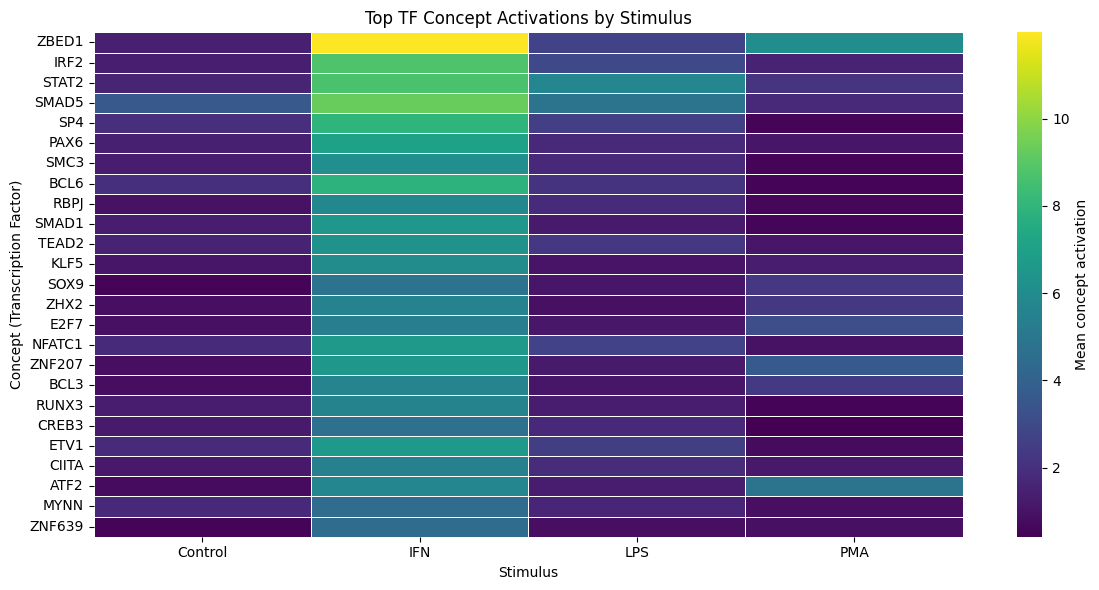

Saved figure: /Users/sally/Desktop/MM-KPNN/exports/concept_activation_heatmap_top25.png

updated_state_log: /Users/sally/Desktop/MM-KPNN/logs/02_train_and_interpret_20260328T164737Z_state.json


In [18]:
# === 02_train_and_interpret.ipynb : Cell 14 ===
# Heatmap of top integrated concepts across stimuli

import matplotlib.pyplot as plt
import seaborn as sns

require("concept_summary" in globals(), "Run Cell 12 (representation summary) first.")

# -------------------------------------------------
# Select top concepts
# -------------------------------------------------
TOP_N = 25

top_concepts = concept_summary.head(TOP_N).index.tolist()

heatmap_df = (
    test_concepts_annot
    .groupby("stim_type")[top_concepts]
    .mean()
)

# Order stimuli for readability
stimulus_order = ["Control", "IFN", "LPS", "PMA"]
heatmap_df = heatmap_df.loc[stimulus_order]

# -------------------------------------------------
# Plot heatmap
# -------------------------------------------------
plt.figure(figsize=(12, 6))

sns.heatmap(
    heatmap_df.T,
    cmap="viridis",
    linewidths=0.5,
    cbar_kws={"label": "Mean concept activation"}
)

plt.title("Top TF Concept Activations by Stimulus")
plt.xlabel("Stimulus")
plt.ylabel("Concept (Transcription Factor)")

plt.tight_layout()

# -------------------------------------------------
# Save figure
# -------------------------------------------------
fig_path = EXPORT_DIR / "concept_activation_heatmap_top25.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved figure:", fig_path.resolve())

nested_register(
    "figures",
    "concept_activation_heatmap",
    {"path": str(fig_path.resolve()), "n_concepts": TOP_N},
    overwrite=True
)

state_path = save_state()
print(f"\nupdated_state_log: {state_path.resolve()}")

## 11. Summary tables and exports

### Build the integrated PBMC summary table

Combine structural, selectivity, attribution, and output-layer summaries into the exported PBMC concept summary table.

In [19]:
# === Cell 15: experiment summary ===

# Recompute concept activity fraction from test concept activations
concept_activity_fraction = (test_concepts.detach().cpu().numpy() > 0).mean(axis=0)

summary = {
    "dataset": "GSE178429_PBMC_stimulation",
    "n_cells": int(adata_primary.n_obs),
    "n_genes": int(adata_primary.n_vars),
    "n_concepts": int(mask_tensor.shape[1]),
    "test_accuracy": float(test_accuracy),
    "dead_concepts": int((concept_activity_fraction == 0).sum()),
    "rare_concepts_lt1pct": int((concept_activity_fraction < 0.01).sum()),
    "mean_active_fraction": float(concept_activity_fraction.mean()),
    "median_active_fraction": float(np.median(concept_activity_fraction)),
    "mean_selectivity": float(selectivity_df["selectivity_score"].mean()),
    "median_selectivity": float(selectivity_df["selectivity_score"].median()),
    "top_integrated_concept": str(concept_summary.index[0]),
    "top_concept_preferred_stimulus": str(concept_summary.iloc[0]["preferred_stimulus"]),
}

summary_df = pd.DataFrame(summary.items(), columns=["metric", "value"])

print("MM-KPNN experiment summary")
display(summary_df)

MM-KPNN experiment summary


,metric,value
0,dataset,GSE178429_PBMC_stimulation
1,n_cells,19268
2,n_genes,19222
3,n_concepts,315
4,test_accuracy,0.863369
5,dead_concepts,0
6,rare_concepts_lt1pct,4
7,mean_active_fraction,0.826995
8,median_active_fraction,0.911795
9,mean_selectivity,1.542091


In [20]:
# === Cell 16: export run summary ===

summary_path_tsv = EXPORT_DIR / "run_summary.tsv"
summary_path_json = EXPORT_DIR / "run_summary.json"

summary_df.to_csv(summary_path_tsv, sep="\t", index=False)

import json
with open(summary_path_json, "w") as f:
    json.dump(summary, f, indent=2)

print("Saved run summary")
print(summary_path_tsv.resolve())
print(summary_path_json.resolve())

Saved run summary
/Users/sally/Desktop/MM-KPNN/exports/run_summary.tsv
/Users/sally/Desktop/MM-KPNN/exports/run_summary.json


### Export run summary

Save the main PBMC summary artifacts for downstream comparison and figure generation.

### PBMC mechanistic expectation framework

Define the stimulus-specific biological expectations used for mechanistic evaluation.

In [21]:
# === PBMC mechanistic expectation framework ===

import pandas as pd

mechanistic_expectation_rows = [
    {
        "stimulus": "Control",
        "expected_concepts_up": [],
        "expected_concepts_down": ["STAT1", "STAT2", "IRF7", "IRF9", "NFKB1_RELA", "REL", "NFATC2", "NR4A1"],
        "expected_responding_cell_types": [],
        "expected_gene_level_drivers": [],
    },
    {
        "stimulus": "IFN",
        "expected_concepts_up": ["STAT1", "STAT2", "IRF7", "IRF9", "IRF1", "CIITA"],
        "expected_concepts_down": ["NFKB1_RELA", "REL", "NFATC2", "NR4A1"],
        "expected_responding_cell_types": ["monocytes", "dendritic cells", "B cells", "T cells", "NK cells"],
        "expected_gene_level_drivers": ["ISG15", "IFIT1", "IFIT2", "IFIT3", "MX1", "OAS1", "OAS2", "OAS3", "IFI6", "IFI44L", "RSAD2", "CXCL10"],
    },
    {
        "stimulus": "LPS",
        "expected_concepts_up": ["NFKB1_RELA", "REL", "NFKB2", "JUN", "JUNB", "FOS", "ATF2", "CEBPB", "IRF1"],
        "expected_concepts_down": ["STAT1", "STAT2", "IRF7", "IRF9"],
        "expected_responding_cell_types": ["CD14+ monocytes", "FCGR3A+ monocytes", "dendritic cells"],
        "expected_gene_level_drivers": ["TNF", "IL1B", "IL6", "CXCL8", "CCL3", "CCL4", "NFKBIA", "PTGS2"],
    },
    {
        "stimulus": "PMA",
        "expected_concepts_up": ["REL", "NFKB1_RELA", "FOS", "FOSB", "JUN", "JUNB", "ATF2", "NFATC2", "NR4A1", "NR4A2"],
        "expected_concepts_down": ["STAT1", "STAT2", "IRF7", "IRF9"],
        "expected_responding_cell_types": ["T cells", "NK cells", "monocytes"],
        "expected_gene_level_drivers": ["FOS", "JUN", "JUNB", "EGR1", "EGR2", "NR4A1", "NR4A2", "DUSP1", "NFKBIA", "IER2"],
    },
]

mechanistic_expectation_df = pd.DataFrame(mechanistic_expectation_rows)

display(mechanistic_expectation_df)

# Save
expectation_path = EXPORT_DIR / "pbmc_mechanistic_expectation_framework.tsv"
mechanistic_expectation_df.to_csv(expectation_path, sep="\t", index=False)

nested_register(
    "interpretability",
    "pbmc_mechanistic_expectation_framework",
    {"path": str(expectation_path.resolve())},
    overwrite=True
)

state_path = save_state()
print("Saved:", expectation_path.resolve())
print("updated_state_log:", state_path.resolve())

,stimulus,expected_concepts_up,expected_concepts_down,expected_responding_cell_types,expected_gene_level_drivers
0,Control,[],"[STAT1, STAT2, IRF7, IRF9, NFKB1_RELA, REL, NF...",[],[]
1,IFN,"[STAT1, STAT2, IRF7, IRF9, IRF1, CIITA]","[NFKB1_RELA, REL, NFATC2, NR4A1]","[monocytes, dendritic cells, B cells, T cells,...","[ISG15, IFIT1, IFIT2, IFIT3, MX1, OAS1, OAS2, ..."
2,LPS,"[NFKB1_RELA, REL, NFKB2, JUN, JUNB, FOS, ATF2,...","[STAT1, STAT2, IRF7, IRF9]","[CD14+ monocytes, FCGR3A+ monocytes, dendritic...","[TNF, IL1B, IL6, CXCL8, CCL3, CCL4, NFKBIA, PT..."
3,PMA,"[REL, NFKB1_RELA, FOS, FOSB, JUN, JUNB, ATF2, ...","[STAT1, STAT2, IRF7, IRF9]","[T cells, NK cells, monocytes]","[FOS, JUN, JUNB, EGR1, EGR2, NR4A1, NR4A2, DUS..."


Saved: /Users/sally/Desktop/MM-KPNN/exports/pbmc_mechanistic_expectation_framework.tsv
updated_state_log: /Users/sally/Desktop/MM-KPNN/logs/02_train_and_interpret_20260328T164737Z_state.json


This table records the expected PBMC regulatory programs used as the reference for downstream mechanistic evaluation.

In [22]:
# === Build PBMC mechanistic evaluation table ===

import numpy as np
import pandas as pd

require("mechanistic_expectation_df" in globals(), "mechanistic_expectation_df is not defined.")
require("mask_df" in globals(), "mask_df is not defined.")

# Expected concept universe restricted to learned concepts
available_concepts = set(mask_df.columns.astype(str))

evaluation_rows = []
for row in mechanistic_expectation_df.itertuples(index=False):
    expected_up = [c for c in row.expected_concepts_up if c in available_concepts]
    expected_down = [c for c in row.expected_concepts_down if c in available_concepts]

    expected_gene_drivers = list(row.expected_gene_level_drivers)
    expected_cell_types = list(row.expected_responding_cell_types)

    regulon_gene_sets = {}
    regulon_sizes = {}
    for concept in expected_up:
        genes = mask_df.index[mask_df[concept].values > 0].astype(str).tolist()
        regulon_gene_sets[concept] = genes
        regulon_sizes[concept] = int(len(genes))

    evaluation_rows.append({
        "stimulus": row.stimulus,
        "expected_concepts_up": expected_up,
        "expected_concepts_down": expected_down,
        "expected_responding_cell_types": expected_cell_types,
        "expected_gene_level_drivers": expected_gene_drivers,
        "n_expected_concepts_up_in_model": int(len(expected_up)),
        "n_expected_concepts_down_in_model": int(len(expected_down)),
        "n_expected_cell_types": int(len(expected_cell_types)),
        "n_expected_gene_drivers": int(len(expected_gene_drivers)),
        "expected_up_regulon_sizes": regulon_sizes,
        "expected_up_regulon_gene_sets": regulon_gene_sets,
    })

pbmc_mechanistic_eval_df = pd.DataFrame(evaluation_rows)

display(pbmc_mechanistic_eval_df)

eval_path = EXPORT_DIR / "pbmc_mechanistic_evaluation_table.tsv"
pbmc_mechanistic_eval_df.to_csv(eval_path, sep="\t", index=False)

nested_register(
    "interpretability",
    "pbmc_mechanistic_evaluation_table",
    {"path": str(eval_path.resolve())},
    overwrite=True
)

state_path = save_state()
print("Saved:", eval_path.resolve())
print("updated_state_log:", state_path.resolve())

,stimulus,expected_concepts_up,expected_concepts_down,expected_responding_cell_types,expected_gene_level_drivers,n_expected_concepts_up_in_model,n_expected_concepts_down_in_model,n_expected_cell_types,n_expected_gene_drivers,expected_up_regulon_sizes,expected_up_regulon_gene_sets
0,Control,[],"[STAT2, IRF9, NFKB1_RELA, REL, NFATC2, NR4A1]",[],[],0,6,0,0,{},{}
1,IFN,"[STAT2, IRF9, CIITA]","[NFKB1_RELA, REL, NFATC2, NR4A1]","[monocytes, dendritic cells, B cells, T cells,...","[ISG15, IFIT1, IFIT2, IFIT3, MX1, OAS1, OAS2, ...",3,4,5,12,"{'STAT2': 410, 'IRF9': 348, 'CIITA': 28}","{'STAT2': ['ISG15', 'AGRN', 'NADK', 'RERE', 'M..."
2,LPS,"[NFKB1_RELA, REL, NFKB2, ATF2]","[STAT2, IRF9]","[CD14+ monocytes, FCGR3A+ monocytes, dendritic...","[TNF, IL1B, IL6, CXCL8, CCL3, CCL4, NFKBIA, PT...",4,2,3,8,"{'NFKB1_RELA': 16, 'REL': 43, 'NFKB2': 403, 'A...","{'NFKB1_RELA': ['RELA', 'BIRC3', 'BIRC2', 'NOS..."
3,PMA,"[REL, NFKB1_RELA, ATF2, NFATC2, NR4A1]","[STAT2, IRF9]","[T cells, NK cells, monocytes]","[FOS, JUN, JUNB, EGR1, EGR2, NR4A1, NR4A2, DUS...",5,2,3,10,"{'REL': 43, 'NFKB1_RELA': 16, 'ATF2': 482, 'NF...","{'REL': ['EPHB2', 'JUN', 'F3', 'CRP', 'SELE', ..."


Saved: /Users/sally/Desktop/MM-KPNN/exports/pbmc_mechanistic_evaluation_table.tsv
updated_state_log: /Users/sally/Desktop/MM-KPNN/logs/02_train_and_interpret_20260328T164737Z_state.json


PBMC mechanistic concept activations by condition


,STAT2,IRF9,CIITA,NFKB1_RELA,REL,NFKB2,ATF2,NFATC2,NR4A1
stimulus,,,,,,,,,
Control,1.572287,1.144046,1.184222,0.121574,0.472495,1.470000,0.779535,0.000172,0.542656
IFN,8.654427,2.236017,5.391310,0.277631,2.843559,4.336084,5.703303,0.001327,1.562314
LPS,5.709068,2.767961,1.826573,0.223885,0.993470,1.850671,1.276904,0.000308,1.022111
PMA,2.158433,0.714037,1.143350,0.579685,0.727154,0.594313,4.809407,0.000098,1.359728


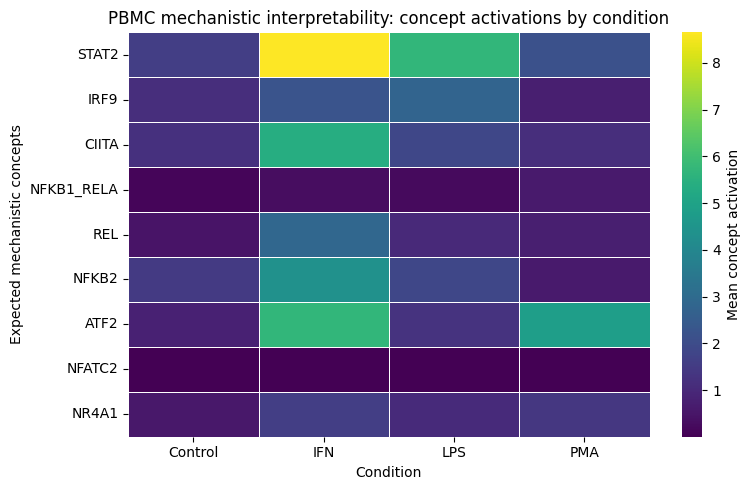

Saved table : /Users/sally/Desktop/MM-KPNN/exports/pbmc_mechanistic_concept_activations_by_condition.tsv
Saved figure: /Users/sally/Desktop/MM-KPNN/exports/pbmc_mechanistic_concept_activations_by_condition.png
updated_state_log: /Users/sally/Desktop/MM-KPNN/logs/02_train_and_interpret_20260328T164737Z_state.json


In [23]:
# === PBMC mechanistic interpretability: concept activations by condition ===

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

require("test_concepts_df" in globals(), "test_concepts_df is not defined.")
require("adata_primary" in globals(), "adata_primary is not defined.")
require("pbmc_mechanistic_eval_df" in globals(), "pbmc_mechanistic_eval_df is not defined.")

# -------------------------------------------------
# Join test concept activations with stimulus labels
# -------------------------------------------------
test_obs = adata_primary.obs.loc[test_concepts_df.index].copy()
require("stim_type" in test_obs.columns, "stim_type missing from test metadata.")

test_concepts_mech = test_concepts_df.copy()
test_concepts_mech["stimulus"] = test_obs["stim_type"].astype(str).values

stimulus_order = ["Control", "IFN", "LPS", "PMA"]
present_stimuli = [s for s in stimulus_order if s in test_concepts_mech["stimulus"].unique()]

# -------------------------------------------------
# Collect expected-up concepts represented in model
# -------------------------------------------------
expected_concepts = []
for row in pbmc_mechanistic_eval_df.itertuples(index=False):
    expected_concepts.extend(list(row.expected_concepts_up))

expected_concepts = [c for c in pd.unique(expected_concepts) if c in test_concepts_df.columns]

require(len(expected_concepts) > 0, "No expected concepts from the PBMC framework are present in test_concepts_df.")

# -------------------------------------------------
# Mean concept activation by stimulus
# -------------------------------------------------
pbmc_mech_concept_activation_df = (
    test_concepts_mech
    .groupby("stimulus")[expected_concepts]
    .mean()
    .reindex(present_stimuli)
)

print("PBMC mechanistic concept activations by condition")
display(pbmc_mech_concept_activation_df)

# -------------------------------------------------
# Plot heatmap
# -------------------------------------------------
plt.figure(figsize=(max(8, len(present_stimuli) * 1.6), max(5, len(expected_concepts) * 0.45)))

sns.heatmap(
    pbmc_mech_concept_activation_df.T,
    cmap="viridis",
    linewidths=0.5,
    cbar_kws={"label": "Mean concept activation"}
)

plt.title("PBMC mechanistic interpretability: concept activations by condition")
plt.xlabel("Condition")
plt.ylabel("Expected mechanistic concepts")

plt.tight_layout()

fig_path = EXPORT_DIR / "pbmc_mechanistic_concept_activations_by_condition.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

# -------------------------------------------------
# Save table
# -------------------------------------------------
table_path = EXPORT_DIR / "pbmc_mechanistic_concept_activations_by_condition.tsv"
pbmc_mech_concept_activation_df.to_csv(table_path, sep="\t")

nested_register(
    "interpretability",
    "pbmc_mechanistic_concept_activations_by_condition",
    {
        "table_path": str(table_path.resolve()),
        "figure_path": str(fig_path.resolve()),
        "n_concepts": int(len(expected_concepts)),
    },
    overwrite=True
)

state_path = save_state()
print("Saved table :", table_path.resolve())
print("Saved figure:", fig_path.resolve())
print("updated_state_log:", state_path.resolve())

,STAT2,IRF9,CIITA,NFKB1_RELA,REL,NFKB2,ATF2,NFATC2,NR4A1
stimulus,,,,,,,,,
Control,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
IFN,7.082139,1.091971,4.207088,0.156056,2.371064,2.866084,4.923769,0.001155,1.019658
LPS,4.136781,1.623915,0.642352,0.102311,0.520975,0.380671,0.497370,0.000136,0.479455
PMA,0.586146,-0.430009,-0.040872,0.458111,0.254659,-0.875687,4.029872,-0.000074,0.817072


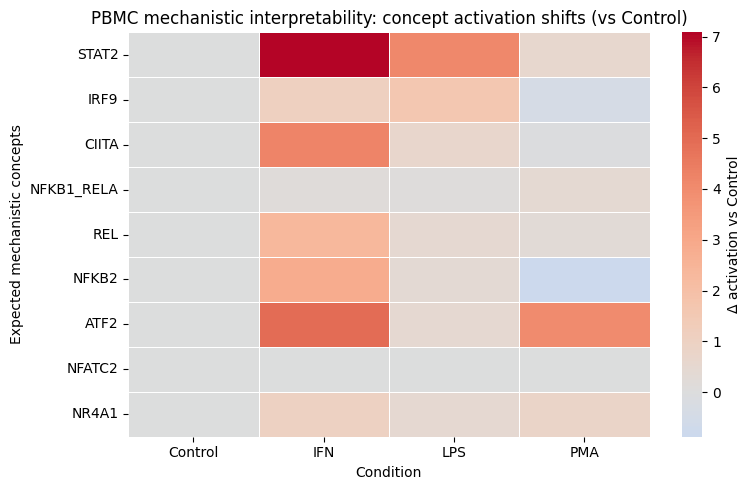

Saved table : /Users/sally/Desktop/MM-KPNN/exports/pbmc_mechanistic_concept_activation_delta_vs_control.tsv
Saved figure: /Users/sally/Desktop/MM-KPNN/exports/pbmc_mechanistic_concept_activation_delta_vs_control.png
updated_state_log: /Users/sally/Desktop/MM-KPNN/logs/02_train_and_interpret_20260328T164737Z_state.json


In [24]:
# === PBMC mechanistic interpretability: concept activations (delta vs Control) ===

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

require("pbmc_mech_concept_activation_df" in globals(), "pbmc_mech_concept_activation_df is not defined.")

require("Control" in pbmc_mech_concept_activation_df.index, "Control condition missing.")

# -------------------------------------------------
# Delta vs Control
# -------------------------------------------------
control_values = pbmc_mech_concept_activation_df.loc["Control"]

pbmc_mech_delta_df = pbmc_mech_concept_activation_df.subtract(control_values, axis=1)

display(pbmc_mech_delta_df)

# -------------------------------------------------
# Plot heatmap
# -------------------------------------------------
plt.figure(figsize=(8, max(5, pbmc_mech_delta_df.shape[1] * 0.45)))

sns.heatmap(
    pbmc_mech_delta_df.T,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Δ activation vs Control"}
)

plt.title("PBMC mechanistic interpretability: concept activation shifts (vs Control)")
plt.xlabel("Condition")
plt.ylabel("Expected mechanistic concepts")

plt.tight_layout()

fig_path = EXPORT_DIR / "pbmc_mechanistic_concept_activation_delta_vs_control.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

# -------------------------------------------------
# Save
# -------------------------------------------------
table_path = EXPORT_DIR / "pbmc_mechanistic_concept_activation_delta_vs_control.tsv"
pbmc_mech_delta_df.to_csv(table_path, sep="\t")

nested_register(
    "interpretability",
    "pbmc_mechanistic_concept_activation_delta_vs_control",
    {
        "table_path": str(table_path.resolve()),
        "figure_path": str(fig_path.resolve()),
    },
    overwrite=True
)

state_path = save_state()
print("Saved table :", table_path.resolve())
print("Saved figure:", fig_path.resolve())
print("updated_state_log:", state_path.resolve())

,stimulus,concept,top_k,aligned_regulon_size,top_gene_count,overlap_n,overlap_fraction_of_topk,overlap_fraction_of_regulon
0,IFN,STAT2,50,410,50,50,1.00,0.121951
1,IFN,IRF9,50,348,50,50,1.00,0.143678
2,IFN,CIITA,50,28,50,28,0.56,1.000000
3,LPS,NFKB2,50,403,50,50,1.00,0.124069
4,LPS,ATF2,50,482,50,50,1.00,0.103734
5,LPS,REL,50,43,50,43,0.86,1.000000
6,LPS,NFKB1_RELA,50,16,50,16,0.32,1.000000
7,PMA,ATF2,50,482,50,50,1.00,0.103734
8,PMA,NR4A1,50,433,50,50,1.00,0.115473
9,PMA,REL,50,43,50,43,0.86,1.000000


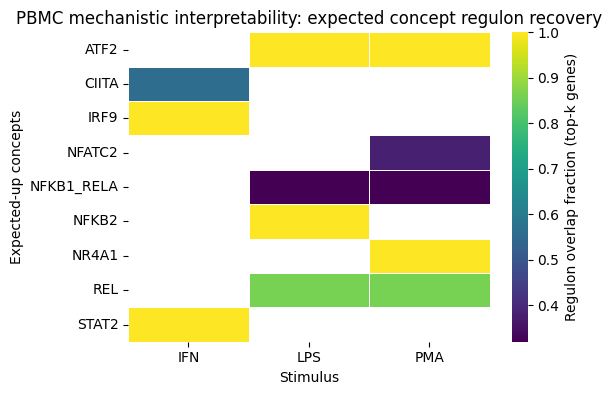

Saved table : /Users/sally/Desktop/MM-KPNN/exports/pbmc_expected_concept_regulon_recovery.tsv
Saved figure: /Users/sally/Desktop/MM-KPNN/exports/pbmc_expected_concept_regulon_recovery.png
updated_state_log: /Users/sally/Desktop/MM-KPNN/logs/02_train_and_interpret_20260328T164737Z_state.json


In [25]:
# === PBMC mechanistic interpretability: expected concept regulon recovery ===

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

require("pbmc_mechanistic_eval_df" in globals(), "pbmc_mechanistic_eval_df is not defined.")
require("pbmc_concept_df" in globals(), "pbmc_concept_df is not defined.")

# -------------------------------------------------
# Collect expected-up concepts by stimulus
# -------------------------------------------------
expected_rows = []

for row in pbmc_mechanistic_eval_df.itertuples(index=False):
    for concept in row.expected_concepts_up:
        expected_rows.append({
            "stimulus": row.stimulus,
            "concept": concept
        })

expected_concepts_df = pd.DataFrame(expected_rows)

require(len(expected_concepts_df) > 0, "No expected concepts available for PBMC mechanistic analysis.")

# -------------------------------------------------
# Join with concept-level regulon recovery
# -------------------------------------------------
pbmc_expected_concordance_df = (
    expected_concepts_df
    .merge(pbmc_concept_df.copy(), on="concept", how="left")
    .sort_values(["stimulus", "overlap_fraction_of_topk"], ascending=[True, False])
    .reset_index(drop=True)
)

display(pbmc_expected_concordance_df)

# -------------------------------------------------
# Heatmap input
# -------------------------------------------------
plot_df = (
    pbmc_expected_concordance_df
    .pivot(index="concept", columns="stimulus", values="overlap_fraction_of_topk")
)

stimulus_order = [s for s in ["Control", "IFN", "LPS", "PMA"] if s in plot_df.columns]
plot_df = plot_df.reindex(columns=stimulus_order)

plt.figure(figsize=(max(6, len(stimulus_order) * 1.5), max(4, plot_df.shape[0] * 0.45)))

sns.heatmap(
    plot_df,
    cmap="viridis",
    linewidths=0.5,
    cbar_kws={"label": "Regulon overlap fraction (top-k genes)"}
)

plt.title("PBMC mechanistic interpretability: expected concept regulon recovery")
plt.xlabel("Stimulus")
plt.ylabel("Expected-up concepts")

plt.tight_layout()

fig_path = EXPORT_DIR / "pbmc_expected_concept_regulon_recovery.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

# -------------------------------------------------
# Save
# -------------------------------------------------
table_path = EXPORT_DIR / "pbmc_expected_concept_regulon_recovery.tsv"
pbmc_expected_concordance_df.to_csv(table_path, sep="\t", index=False)

nested_register(
    "interpretability",
    "pbmc_expected_concept_regulon_recovery",
    {
        "table_path": str(table_path.resolve()),
        "figure_path": str(fig_path.resolve()),
    },
    overwrite=True
)

state_path = save_state()
print("Saved table :", table_path.resolve())
print("Saved figure:", fig_path.resolve())
print("updated_state_log:", state_path.resolve())

In [26]:
# === PBMC mechanistic summary table (final) ===

import pandas as pd

require("pbmc_mechanistic_eval_df" in globals(), "pbmc_mechanistic_eval_df is not defined.")
require("pbmc_mech_delta_df" in globals(), "pbmc_mech_delta_df is not defined.")
require("pbmc_expected_concordance_df" in globals(), "pbmc_expected_concordance_df is not defined.")

summary_rows = []

for row in pbmc_mechanistic_eval_df.itertuples(index=False):
    stimulus = row.stimulus

    for concept in row.expected_concepts_up:
        if concept not in pbmc_mech_delta_df.columns:
            continue

        delta_activation = float(pbmc_mech_delta_df.loc[stimulus, concept])

        concordance_row = pbmc_expected_concordance_df[
            (pbmc_expected_concordance_df["stimulus"] == stimulus) &
            (pbmc_expected_concordance_df["concept"] == concept)
        ]

        if len(concordance_row) == 0:
            overlap_top = None
            overlap_regulon = None
        else:
            overlap_top = float(concordance_row["overlap_fraction_of_topk"].values[0])
            overlap_regulon = float(concordance_row["overlap_fraction_of_regulon"].values[0])

        summary_rows.append({
            "stimulus": stimulus,
            "concept": concept,
            "delta_activation_vs_control": delta_activation,
            "overlap_fraction_topk": overlap_top,
            "overlap_fraction_regulon": overlap_regulon,
        })

pbmc_mechanistic_summary_df = pd.DataFrame(summary_rows)

# -------------------------------------------------
# Add qualitative flags
# -------------------------------------------------
def classify_activation(x):
    if x is None:
        return "missing"
    if x > 1.0:
        return "strong_up"
    elif x > 0.25:
        return "moderate_up"
    elif x > 0:
        return "weak_up"
    else:
        return "not_up"

def classify_concordance(x):
    if x is None:
        return "missing"
    if x >= 0.75:
        return "high"
    elif x >= 0.4:
        return "moderate"
    else:
        return "low"

pbmc_mechanistic_summary_df["activation_class"] = pbmc_mechanistic_summary_df["delta_activation_vs_control"].apply(classify_activation)
pbmc_mechanistic_summary_df["concordance_class"] = pbmc_mechanistic_summary_df["overlap_fraction_topk"].apply(classify_concordance)

# -------------------------------------------------
# Sort for readability
# -------------------------------------------------
pbmc_mechanistic_summary_df = pbmc_mechanistic_summary_df.sort_values(
    ["stimulus", "delta_activation_vs_control"],
    ascending=[True, False]
).reset_index(drop=True)

display(pbmc_mechanistic_summary_df)

# -------------------------------------------------
# Save
# -------------------------------------------------
table_path = EXPORT_DIR / "pbmc_mechanistic_summary_table.tsv"
pbmc_mechanistic_summary_df.to_csv(table_path, sep="\t", index=False)

nested_register(
    "interpretability",
    "pbmc_mechanistic_summary_table",
    {
        "path": str(table_path.resolve()),
        "n_rows": int(len(pbmc_mechanistic_summary_df)),
    },
    overwrite=True
)

state_path = save_state()
print("Saved:", table_path.resolve())
print("updated_state_log:", state_path.resolve())

,stimulus,concept,delta_activation_vs_control,overlap_fraction_topk,overlap_fraction_regulon,activation_class,concordance_class
0,IFN,STAT2,7.082139,1.00,0.121951,strong_up,high
1,IFN,CIITA,4.207088,0.56,1.000000,strong_up,moderate
2,IFN,IRF9,1.091971,1.00,0.143678,strong_up,high
3,LPS,REL,0.520975,0.86,1.000000,moderate_up,high
4,LPS,ATF2,0.497370,1.00,0.103734,moderate_up,high
5,LPS,NFKB2,0.380671,1.00,0.124069,moderate_up,high
6,LPS,NFKB1_RELA,0.102311,0.32,1.000000,weak_up,low
7,PMA,ATF2,4.029872,1.00,0.103734,strong_up,high
8,PMA,NR4A1,0.817072,1.00,0.115473,moderate_up,high
9,PMA,NFKB1_RELA,0.458111,0.32,1.000000,moderate_up,low


Saved: /Users/sally/Desktop/MM-KPNN/exports/pbmc_mechanistic_summary_table.tsv
updated_state_log: /Users/sally/Desktop/MM-KPNN/logs/02_train_and_interpret_20260328T164737Z_state.json


,stimulus,concept,activation_expected_condition,max_activation_other_conditions,mean_activation_other_conditions,selectivity_vs_max_other,selectivity_vs_mean_other,specificity_ratio_vs_max_other,specificity_ratio_vs_mean_other,selectivity_class
0,IFN,CIITA,5.391310,1.826573,1.384715,3.564737,4.006595,2.951598,3.893445,high
1,IFN,STAT2,8.654427,5.709068,3.146596,2.945359,5.507831,1.515909,2.750409,high
2,IFN,IRF9,2.236017,2.767961,1.542015,-0.531944,0.694002,0.807821,1.450062,low
3,LPS,NFKB1_RELA,0.223885,0.579685,0.326297,-0.355800,-0.102412,0.386218,0.686140,low
4,LPS,REL,0.993470,2.843559,1.347736,-1.850089,-0.354266,0.349376,0.737140,low
5,LPS,NFKB2,1.850671,4.336084,2.133466,-2.485413,-0.282795,0.426807,0.867448,low
6,LPS,ATF2,1.276904,5.703303,3.764081,-4.426399,-2.487177,0.223889,0.339234,low
7,PMA,NFKB1_RELA,0.579685,0.277631,0.207697,0.302055,0.371989,2.087974,2.791018,moderate
8,PMA,NFATC2,0.000098,0.001327,0.000602,-0.001229,-0.000504,0.074060,0.163163,low
9,PMA,NR4A1,1.359728,1.562314,1.042360,-0.202586,0.317367,0.870329,1.304470,low


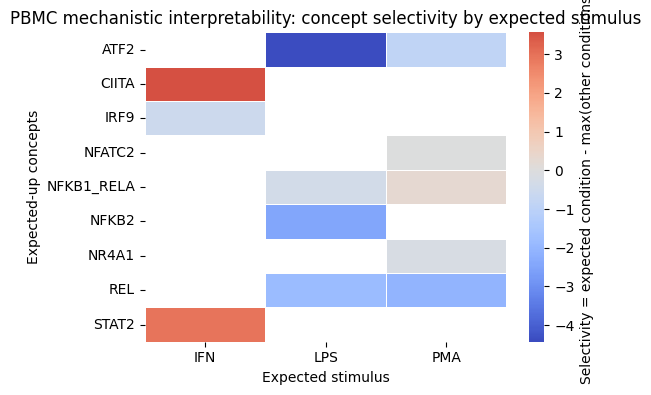

Saved table : /Users/sally/Desktop/MM-KPNN/exports/pbmc_concept_selectivity_by_expected_stimulus.tsv
Saved figure: /Users/sally/Desktop/MM-KPNN/exports/pbmc_concept_selectivity_by_expected_stimulus.png
updated_state_log: /Users/sally/Desktop/MM-KPNN/logs/02_train_and_interpret_20260328T164737Z_state.json


In [27]:
# === PBMC mechanistic interpretability: concept selectivity by expected stimulus ===

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

require("pbmc_mech_concept_activation_df" in globals(), "pbmc_mech_concept_activation_df is not defined.")
require("pbmc_mechanistic_eval_df" in globals(), "pbmc_mechanistic_eval_df is not defined.")

selectivity_rows = []

for row in pbmc_mechanistic_eval_df.itertuples(index=False):
    stimulus = row.stimulus

    if stimulus not in pbmc_mech_concept_activation_df.index:
        continue

    other_stimuli = [s for s in pbmc_mech_concept_activation_df.index if s != stimulus]

    for concept in row.expected_concepts_up:
        if concept not in pbmc_mech_concept_activation_df.columns:
            continue
        if len(other_stimuli) == 0:
            continue

        activation_expected = float(pbmc_mech_concept_activation_df.loc[stimulus, concept])
        max_other = float(pbmc_mech_concept_activation_df.loc[other_stimuli, concept].max())
        mean_other = float(pbmc_mech_concept_activation_df.loc[other_stimuli, concept].mean())

        selectivity_vs_max_other = activation_expected - max_other
        selectivity_vs_mean_other = activation_expected - mean_other

        if activation_expected > 0:
            specificity_ratio_vs_max = activation_expected / max_other if max_other > 0 else float("inf")
            specificity_ratio_vs_mean = activation_expected / mean_other if mean_other > 0 else float("inf")
        else:
            specificity_ratio_vs_max = 0.0
            specificity_ratio_vs_mean = 0.0

        selectivity_rows.append({
            "stimulus": stimulus,
            "concept": concept,
            "activation_expected_condition": activation_expected,
            "max_activation_other_conditions": max_other,
            "mean_activation_other_conditions": mean_other,
            "selectivity_vs_max_other": selectivity_vs_max_other,
            "selectivity_vs_mean_other": selectivity_vs_mean_other,
            "specificity_ratio_vs_max_other": specificity_ratio_vs_max,
            "specificity_ratio_vs_mean_other": specificity_ratio_vs_mean,
        })

pbmc_selectivity_df = pd.DataFrame(selectivity_rows)

require(len(pbmc_selectivity_df) > 0, "No selectivity rows were generated.")

def classify_selectivity(x):
    if x > 1.0:
        return "high"
    elif x > 0.25:
        return "moderate"
    else:
        return "low"

pbmc_selectivity_df["selectivity_class"] = pbmc_selectivity_df["selectivity_vs_max_other"].apply(classify_selectivity)

pbmc_selectivity_df = pbmc_selectivity_df.sort_values(
    ["stimulus", "selectivity_vs_max_other"],
    ascending=[True, False]
).reset_index(drop=True)

display(pbmc_selectivity_df)

# -------------------------------------------------
# Heatmap
# -------------------------------------------------
plot_df = pbmc_selectivity_df.pivot(
    index="concept",
    columns="stimulus",
    values="selectivity_vs_max_other"
)

stimulus_order = [s for s in ["Control", "IFN", "LPS", "PMA"] if s in plot_df.columns]
plot_df = plot_df.reindex(columns=stimulus_order)

plt.figure(figsize=(max(6, len(plot_df.columns) * 1.5), max(4, plot_df.shape[0] * 0.45)))

sns.heatmap(
    plot_df,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Selectivity = expected condition - max(other conditions)"}
)

plt.title("PBMC mechanistic interpretability: concept selectivity by expected stimulus")
plt.xlabel("Expected stimulus")
plt.ylabel("Expected-up concepts")

plt.tight_layout()

fig_path = EXPORT_DIR / "pbmc_concept_selectivity_by_expected_stimulus.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

# -------------------------------------------------
# Save
# -------------------------------------------------
table_path = EXPORT_DIR / "pbmc_concept_selectivity_by_expected_stimulus.tsv"
pbmc_selectivity_df.to_csv(table_path, sep="\t", index=False)

nested_register(
    "interpretability",
    "pbmc_concept_selectivity_by_expected_stimulus",
    {
        "table_path": str(table_path.resolve()),
        "figure_path": str(fig_path.resolve()),
    },
    overwrite=True
)

state_path = save_state()
print("Saved table :", table_path.resolve())
print("Saved figure:", fig_path.resolve())
print("updated_state_log:", state_path.resolve())

In [28]:
# === Cell 18: artifact manifest ===

print("MM-KPNN artifact manifest")
print("--------------------------")

artifacts = {
    "gene_universe": ARTIFACTS_DIR / "gene_universe.tsv",
    "gene_identifier_audit": ARTIFACTS_DIR / "gene_identifier_audit.tsv",
    "pruned_regulons": ARTIFACTS_DIR / "tf_regulons_pruned.tsv",
    "gene_concept_mask": ARTIFACTS_DIR / "gene_concept_mask.tsv",
    "concept_sizes": ARTIFACTS_DIR / "concept_sizes.tsv",
    "gene_concept_degree": ARTIFACTS_DIR / "gene_concept_degree.tsv",
    "benchmark_splits": ARTIFACTS_DIR / "benchmark_splits.tsv",
}

exports = {
    "training_history": EXPORT_DIR / "training_history.tsv",
    "train_concepts": EXPORT_DIR / "train_concept_activations.tsv",
    "val_concepts": EXPORT_DIR / "val_concept_activations.tsv",
    "test_concepts": EXPORT_DIR / "test_concept_activations.tsv",
    "concept_selectivity": EXPORT_DIR / "concept_selectivity_by_stimulus.tsv",
    "concept_importance_Control": EXPORT_DIR / "concept_importance_Control.tsv",
    "concept_importance_IFN": EXPORT_DIR / "concept_importance_IFN.tsv",
    "concept_importance_LPS": EXPORT_DIR / "concept_importance_LPS.tsv",
    "concept_importance_PMA": EXPORT_DIR / "concept_importance_PMA.tsv",
    "concept_summary": EXPORT_DIR / "concept_representation_summary.tsv",
    "stimulus_summary": EXPORT_DIR / "stimulus_preferred_concept_counts.tsv",
    "confusion_matrix_counts": EXPORT_DIR / "test_confusion_matrix_counts.tsv",
    "confusion_matrix_normalized": EXPORT_DIR / "test_confusion_matrix_normalized.tsv",
    "classification_report": EXPORT_DIR / "test_classification_report.tsv",
    "concept_heatmap": EXPORT_DIR / "concept_activation_heatmap_top25.png",
    "run_summary_tsv": EXPORT_DIR / "run_summary.tsv",
    "run_summary_json": EXPORT_DIR / "run_summary.json",
}

print("\nArtifacts")
for k, v in artifacts.items():
    print(f"{k}: {v}")

print("\nExports")
for k, v in exports.items():
    print(f"{k}: {v}")

MM-KPNN artifact manifest
--------------------------

Artifacts
gene_universe: /Users/sally/Desktop/MM-KPNN/artifacts/gene_universe.tsv
gene_identifier_audit: /Users/sally/Desktop/MM-KPNN/artifacts/gene_identifier_audit.tsv
pruned_regulons: /Users/sally/Desktop/MM-KPNN/artifacts/tf_regulons_pruned.tsv
gene_concept_mask: /Users/sally/Desktop/MM-KPNN/artifacts/gene_concept_mask.tsv
concept_sizes: /Users/sally/Desktop/MM-KPNN/artifacts/concept_sizes.tsv
gene_concept_degree: /Users/sally/Desktop/MM-KPNN/artifacts/gene_concept_degree.tsv
benchmark_splits: /Users/sally/Desktop/MM-KPNN/artifacts/benchmark_splits.tsv

Exports
training_history: /Users/sally/Desktop/MM-KPNN/exports/training_history.tsv
train_concepts: /Users/sally/Desktop/MM-KPNN/exports/train_concept_activations.tsv
val_concepts: /Users/sally/Desktop/MM-KPNN/exports/val_concept_activations.tsv
test_concepts: /Users/sally/Desktop/MM-KPNN/exports/test_concept_activations.tsv
concept_selectivity: /Users/sally/Desktop/MM-KPNN/expor

## 12. Stability analysis

In [30]:
# === PBMC Stability Cell A: export run-level stability artifacts ===

import json
from pathlib import Path
import numpy as np
import pandas as pd
import torch

# -------------------------------------------------
# 0. Required objects (must exist before running)
# -------------------------------------------------
required_globals = [
    "model",
    "adata_primary",
    "X_test_tensor",
    "y_test_tensor",
    "concept_means_by_stim",
    "class_names",
]
missing = [name for name in required_globals if name not in globals()]
if missing:
    raise NameError("Missing required variables:\n" + "\n".join(missing))

# -------------------------------------------------
# 1. Seed (fallback if not stored)
# -------------------------------------------------
resolved_seed = globals().get("SEED", 0)

# -------------------------------------------------
# 2. Setup
# -------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(DEVICE)
model.eval()

PBMC_CONDITIONS = ["Control", "IFN", "LPS", "PMA"]
TOP_CONCEPTS = 5
TOP_DRIVER_GENES = 20

pbmc_class_names = [str(x) for x in class_names]
gene_names = adata_primary.var_names.astype(str).tolist()

# ensure proper indexing
concept_means = concept_means_by_stim.copy()
concept_means.index = concept_means.index.astype(str)
pbmc_conditions = [c for c in PBMC_CONDITIONS if c in concept_means.index]

# -------------------------------------------------
# 3. Gradient helper
# -------------------------------------------------
def forward_logits(model, x_tensor):
    out = model(x_tensor)
    if isinstance(out, tuple):
        return out[0]
    return out

def class_input_gradients(model, x_np, class_idx):
    x_tensor = torch.tensor(
        x_np,
        dtype=torch.float32,
        device=DEVICE,
        requires_grad=True
    )

    logits = forward_logits(model, x_tensor)
    target = logits[:, class_idx].sum()

    grads = torch.autograd.grad(
        outputs=target,
        inputs=x_tensor,
        retain_graph=False,
        create_graph=False
    )[0].detach().cpu().numpy()

    return np.mean(np.abs(grads), axis=0)

# -------------------------------------------------
# 4. Concept profile (long format)
# -------------------------------------------------
concept_profile_df = (
    concept_means
    .loc[pbmc_conditions]
    .copy()
    .reset_index()
    .rename(columns={concept_means.index.name or "index": "stimulus"})
    .melt(id_vars=["stimulus"], var_name="concept", value_name="activation")
)

# -------------------------------------------------
# 5. Top concepts + top genes
# -------------------------------------------------
X_test_np = X_test_tensor.detach().cpu().numpy()
y_test_np = y_test_tensor.detach().cpu().numpy()

top_concept_rows = []
top_gene_rows = []

for stim in pbmc_conditions:
    class_idx = pbmc_class_names.index(stim)
    stim_mask = (y_test_np == class_idx)
    x_stim = X_test_np[stim_mask]

    if x_stim.shape[0] == 0:
        print(f"Skipping {stim}: no test cells")
        continue

    # top concepts
    ranked_concepts = (
        concept_means.loc[stim]
        .astype(float)
        .abs()
        .sort_values(ascending=False)
    )

    for rank, (concept, score) in enumerate(ranked_concepts.head(TOP_CONCEPTS).items(), start=1):
        top_concept_rows.append({
            "stimulus": stim,
            "rank": rank,
            "concept": str(concept),
            "score": float(score),
        })

    # top genes
    gene_scores = class_input_gradients(model, x_stim, class_idx)

    ranked_genes = (
        pd.Series(gene_scores, index=gene_names)
        .sort_values(ascending=False)
    )

    for rank, (gene, score) in enumerate(ranked_genes.head(TOP_DRIVER_GENES).items(), start=1):
        top_gene_rows.append({
            "stimulus": stim,
            "rank": rank,
            "gene": str(gene),
            "score": float(score),
        })

top_concepts_df = pd.DataFrame(top_concept_rows)
top_genes_df = pd.DataFrame(top_gene_rows)

# -------------------------------------------------
# 6. Save
# -------------------------------------------------
PROJECT_ROOT_RESOLVED = Path(PROJECT_ROOT) if "PROJECT_ROOT" in globals() else Path("/Users/sally/Desktop/MM-KPNN")
PBMC_DIR = PROJECT_ROOT_RESOLVED / "pbmc_stability_runs"
PBMC_DIR.mkdir(parents=True, exist_ok=True)

run_dir = PBMC_DIR / f"seed_{int(resolved_seed)}"
run_dir.mkdir(parents=True, exist_ok=True)

concept_profile_df.to_csv(run_dir / "concept_profile_long.csv", index=False)
top_concepts_df.to_csv(run_dir / "top_concepts.csv", index=False)
top_genes_df.to_csv(run_dir / "top_genes.csv", index=False)

with open(run_dir / "metadata.json", "w") as f:
    json.dump(
        {
            "seed": int(resolved_seed),
            "conditions": pbmc_conditions,
            "n_concepts": int(concept_means.shape[1]),
            "top_concepts_k": TOP_CONCEPTS,
            "top_driver_k": TOP_DRIVER_GENES,
        },
        f,
        indent=2
    )

print("\nSaved PBMC stability artifacts to:", run_dir)
display(top_concepts_df.head())
display(top_genes_df.head())


Saved PBMC stability artifacts to: /Users/sally/Desktop/MM-KPNN/pbmc_stability_runs/seed_19


,stimulus,rank,concept,score
0,Control,1,SMAD5,3.620919
1,Control,2,ETV4,2.342215
2,Control,3,BCL6,2.005449
3,Control,4,SP4,1.973448
4,Control,5,KLF1,1.847640


,stimulus,rank,gene,score
0,Control,1,CUX1,0.215097
1,Control,2,NAV2,0.177192
2,Control,3,KALRN,0.166508
3,Control,4,MEF2C,0.150759
4,Control,5,CUEDC1,0.145443


In [31]:
# === PBMC Stability Cell B: load PBMC runs and compute stability summary ===

from pathlib import Path
from itertools import combinations
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

PBMC_STAB_DIR = Path(PROJECT_ROOT) / "pbmc_stability_runs" if "PROJECT_ROOT" in globals() else Path("/Users/sally/Desktop/MM-KPNN/pbmc_stability_runs")
PBMC_CONDITIONS = ["Control", "IFN", "LPS", "PMA"]

def jaccard(a, b):
    a = set(a)
    b = set(b)
    return len(a & b) / len(a | b) if len(a | b) > 0 else np.nan

run_dirs = sorted([p for p in PBMC_STAB_DIR.glob("seed_*") if p.is_dir()])
print("PBMC run dirs found:")
for p in run_dirs:
    print(" -", p)

# use only the first 3 runs for the paper
run_dirs = run_dirs[:3]

if len(run_dirs) < 3:
    raise RuntimeError(f"Need at least 3 PBMC runs, found {len(run_dirs)}")

pbmc_rows = []

for run_dir in run_dirs:
    run_id = run_dir.name

    concept_profile_df = pd.read_csv(run_dir / "concept_profile_long.csv")
    top_concepts_df = pd.read_csv(run_dir / "top_concepts.csv")
    top_genes_df = pd.read_csv(run_dir / "top_genes.csv")

    for stim in PBMC_CONDITIONS:
        sub_concepts = concept_profile_df[concept_profile_df["stimulus"] == stim].copy()
        if sub_concepts.empty:
            continue

        concept_vector = (
            sub_concepts
            .set_index("concept")["activation"]
            .sort_index()
            .astype(float)
        )

        top_concept_set = set(
            top_concepts_df.loc[top_concepts_df["stimulus"] == stim, "concept"].astype(str).tolist()
        )

        top_gene_set = set(
            top_genes_df.loc[top_genes_df["stimulus"] == stim, "gene"].astype(str).tolist()
        )

        pbmc_rows.append({
            "run_id": run_id,
            "stimulus": stim,
            "concept_vector": concept_vector,
            "top_concepts": top_concept_set,
            "top_genes": top_gene_set,
        })

pbmc_stability_df = pd.DataFrame(pbmc_rows)

summary_rows = []

for stim in PBMC_CONDITIONS:
    sub = pbmc_stability_df[pbmc_stability_df["stimulus"] == stim].reset_index(drop=True)
    if len(sub) < 2:
        continue

    concept_corrs = []
    top_concept_jaccards = []
    driver_gene_jaccards = []

    for i, j in combinations(range(len(sub)), 2):
        v1 = sub.loc[i, "concept_vector"]
        v2 = sub.loc[j, "concept_vector"]

        shared = v1.index.intersection(v2.index)
        rho = spearmanr(v1.loc[shared].values, v2.loc[shared].values).correlation
        concept_corrs.append(rho)

        top_concept_jaccards.append(
            jaccard(sub.loc[i, "top_concepts"], sub.loc[j, "top_concepts"])
        )

        driver_gene_jaccards.append(
            jaccard(sub.loc[i, "top_genes"], sub.loc[j, "top_genes"])
        )

    summary_rows.append({
        "dataset": "PBMC",
        "condition": stim,
        "concept_corr_mean": float(np.mean(concept_corrs)),
        "top_concept_jaccard_mean": float(np.mean(top_concept_jaccards)),
        "driver_gene_jaccard_mean": float(np.mean(driver_gene_jaccards)),
    })

pbmc_stability_summary_df = pd.DataFrame(summary_rows)

print("\nPBMC stability summary:")
display(pbmc_stability_summary_df)

PBMC run dirs found:
 - /Users/sally/Desktop/MM-KPNN/pbmc_stability_runs/seed_17
 - /Users/sally/Desktop/MM-KPNN/pbmc_stability_runs/seed_18
 - /Users/sally/Desktop/MM-KPNN/pbmc_stability_runs/seed_19

PBMC stability summary:


,dataset,condition,concept_corr_mean,top_concept_jaccard_mean,driver_gene_jaccard_mean
0,PBMC,Control,0.723357,0.120370,0.337302
1,PBMC,IFN,0.700082,0.157407,0.348659
2,PBMC,LPS,0.732308,0.263228,0.348659
3,PBMC,PMA,0.617246,0.250000,0.412151


In [32]:
# === Export PBMC cross-dataset synthesis table ===

from pathlib import Path
import pandas as pd

if "pbmc_mechanistic_summary_df" not in globals():
    raise RuntimeError(
        "pbmc_mechanistic_summary_df not found.\n"
        "Run: '# === PBMC mechanistic summary table (final) ==='"
    )

if "pbmc_selectivity_df" not in globals():
    raise RuntimeError(
        "pbmc_selectivity_df not found.\n"
        "Run: '# === PBMC mechanistic interpretability: concept selectivity by expected stimulus ==='"
    )

PROJECT_DIR = Path("/Users/sally/Desktop/MM-KPNN")
SYNTHESIS_DIR = PROJECT_DIR / "artifacts" / "cross_dataset_synthesis"
SYNTHESIS_DIR.mkdir(parents=True, exist_ok=True)

pbmc_synthesis_df = pbmc_mechanistic_summary_df.copy()

# --------------------------------------------------
# Use the selectivity table created in the PBMC notebook
# IMPORTANT:
# For Figure 5, use selectivity_vs_mean_other, not selectivity_vs_max_other.
# --------------------------------------------------
required_selectivity_cols = [
    "stimulus",
    "concept",
    "selectivity_vs_mean_other",
]
missing_selectivity_cols = [
    c for c in required_selectivity_cols if c not in pbmc_selectivity_df.columns
]
if missing_selectivity_cols:
    raise RuntimeError(
        "pbmc_selectivity_df is missing required columns: "
        f"{missing_selectivity_cols}"
    )

pbmc_selectivity_export_df = pbmc_selectivity_df[
    ["stimulus", "concept", "selectivity_vs_mean_other"]
].copy()

pbmc_selectivity_export_df = pbmc_selectivity_export_df.rename(columns={
    "selectivity_vs_mean_other": "concept_selectivity",
})

# --------------------------------------------------
# Merge selectivity into synthesis table
# --------------------------------------------------
pbmc_synthesis_df = pbmc_synthesis_df.merge(
    pbmc_selectivity_export_df,
    on=["stimulus", "concept"],
    how="left",
)

missing_after_merge = pbmc_synthesis_df["concept_selectivity"].isna().sum()
if missing_after_merge > 0:
    missing_pairs = (
        pbmc_synthesis_df.loc[
            pbmc_synthesis_df["concept_selectivity"].isna(),
            ["stimulus", "concept"]
        ]
        .drop_duplicates()
        .to_dict(orient="records")
    )
    raise RuntimeError(
        "concept_selectivity is still missing after merge for these stimulus/concept pairs:\n"
        f"{missing_pairs}"
    )

# --------------------------------------------------
# Rename to shared synthesis schema
# --------------------------------------------------
pbmc_synthesis_df = pbmc_synthesis_df.rename(columns={
    "stimulus": "entity",
    "overlap_fraction_regulon": "driver_overlap",
})

pbmc_synthesis_df["dataset"] = "PBMC"

# --------------------------------------------------
# Keep columns needed for Figure 5
# --------------------------------------------------
required_cols = [
    "dataset",
    "entity",
    "concept",
    "delta_activation_vs_control",
    "concept_selectivity",
    "overlap_fraction_topk",
    "driver_overlap",
    "activation_class",
    "concordance_class",
]

missing_cols = [c for c in required_cols if c not in pbmc_synthesis_df.columns]
if missing_cols:
    raise RuntimeError(
        f"PBMC export is missing required columns: {missing_cols}"
    )

pbmc_synthesis_df = pbmc_synthesis_df[required_cols].copy()

pbmc_synthesis_path = SYNTHESIS_DIR / "pbmc_synthesis_table.tsv"
pbmc_synthesis_df.to_csv(pbmc_synthesis_path, sep="\t", index=False)

print("Saved:", pbmc_synthesis_path)
display(pbmc_synthesis_df.head(12))

Saved: /Users/sally/Desktop/MM-KPNN/artifacts/cross_dataset_synthesis/pbmc_synthesis_table.tsv


,dataset,entity,concept,delta_activation_vs_control,concept_selectivity,overlap_fraction_topk,driver_overlap,activation_class,concordance_class
0,PBMC,IFN,STAT2,7.082139,5.507831,1.00,0.121951,strong_up,high
1,PBMC,IFN,CIITA,4.207088,4.006595,0.56,1.000000,strong_up,moderate
2,PBMC,IFN,IRF9,1.091971,0.694002,1.00,0.143678,strong_up,high
3,PBMC,LPS,REL,0.520975,-0.354266,0.86,1.000000,moderate_up,high
4,PBMC,LPS,ATF2,0.497370,-2.487177,1.00,0.103734,moderate_up,high
5,PBMC,LPS,NFKB2,0.380671,-0.282795,1.00,0.124069,moderate_up,high
6,PBMC,LPS,NFKB1_RELA,0.102311,-0.102412,0.32,1.000000,weak_up,low
7,PBMC,PMA,ATF2,4.029872,2.222826,1.00,0.103734,strong_up,high
8,PBMC,PMA,NR4A1,0.817072,0.317367,1.00,0.115473,moderate_up,high
9,PBMC,PMA,NFKB1_RELA,0.458111,0.371989,0.32,1.000000,moderate_up,low
